<pre>
<center><b><h1>Kanasagara Het S.</b></center>     
<pre>    

# Missing value handling  
# Encodeing categorical values
# Scaling numerical values

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv("insurance_fraud_data.csv")
df.sample(5)

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy deductible,annual premium,days open,form defects,fraud reported
196,34753536,38,F,1,77,58201.6,0,1,Own,20104,...,Compact,52923.52156,silver,25240.814150,4707.653492,1000,968.46,9.662151,7,Y
2914,469836288,43,F,1,63,60180.8,1,0,Own,15037,...,Medium,19280.40916,red,38871.525140,2972.499399,1000,999.43,8.360770,6,N
9950,425793024,44,M,1,83,60552.0,1,1,Rent,85077,...,Medium,21819.65299,gray,26684.196280,4085.870539,1000,1726.91,10.690443,6,N
3847,2882304,70,M,0,88,67969.6,1,0,Own,50021,...,Compact,19282.56245,blue,17208.236150,1930.817776,500,1201.41,3.939695,2,N
11794,602069760,38,M,1,82,58155.2,0,1,Own,85063,...,Large,39182.96067,white,7371.833274,7711.520257,1000,999.43,10.400564,4,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12002 entries, 0 to 12001
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   claim_number        12002 non-null  int64  
 1   age_of_driver       12002 non-null  int64  
 2   gender              12002 non-null  object 
 3   marital_status      12002 non-null  object 
 4   safety_rating       12002 non-null  int64  
 5   annual_income       12002 non-null  float64
 6   high_education      12002 non-null  int64  
 7   address_change      12002 non-null  int64  
 8   property_status     12002 non-null  object 
 9   zip_code            12002 non-null  int64  
 10  claim_date          12002 non-null  object 
 11  claim_day_of_week   12002 non-null  object 
 12  accident_site       12002 non-null  object 
 13  past_num_of_claims  12002 non-null  int64  
 14  witness_present     12002 non-null  object 
 15  liab_prct           12002 non-null  int64  
 16  chan

In [5]:
df.isnull().sum()

claim_number          0
age_of_driver         0
gender                0
marital_status        0
safety_rating         0
annual_income         0
high_education        0
address_change        0
property_status       0
zip_code              0
claim_date            0
claim_day_of_week     0
accident_site         0
past_num_of_claims    0
witness_present       0
liab_prct             0
channel               0
police_report         0
age_of_vehicle        0
vehicle_category      0
vehicle_price         0
vehicle_color         0
total_claim           0
injury_claim          0
policy deductible     0
annual premium        0
days open             0
form defects          0
fraud reported        8
dtype: int64

In [7]:
df.rename(columns={"policy deductible" : "policy_deductible" , "annual premium" : "annual_premium" , "days open" : "days_open" 
                  ,"form defects" : "form_defects" , "fraud reported" : "fraud_reported"} , inplace=True)

## 1. null value bov ochhi hati atle cca(drop-row) apply kairu

In [8]:
df.dropna(inplace = True)

In [9]:
df.shape

(11994, 29)

In [10]:
df.sample(5)

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy_deductible,annual_premium,days_open,form_defects,fraud_reported
11536,577124352,39,M,1,94,58614.4,0,1,Rent,20139,...,Large,7932.967195,gray,34975.24753,3895.51193,1000,1622.67,9.057871,3,N
1657,264280320,66,F,1,40,67035.2,1,1,Rent,20111,...,Compact,13138.642480,white,27711.05034,5076.456044,1000,1622.67,8.913594,4,Y
4557,257582592,25,F,1,85,51483.2,0,0,Rent,20105,...,Medium,17686.385400,gray,32653.60307,4204.457297,500,1354.20,4.267790,4,N
1618,256981248,40,F,1,71,59035.2,1,1,Rent,15007,...,Medium,11062.264150,gray,13009.81940,3166.127163,500,1055.60,9.421130,1,N
5676,4064256,63,F,0,69,16291.0,1,0,Own,50047,...,Medium,15079.927280,other,35519.77641,3241.999616,2000,1055.53,9.873811,2,Y


## Outliears Handling

In [11]:
Numerical_columns = df.columns[df.dtypes != "object"]
Numerical_columns

Index(['claim_number', 'age_of_driver', 'safety_rating', 'annual_income',
       'high_education', 'address_change', 'zip_code', 'past_num_of_claims',
       'liab_prct', 'police_report', 'vehicle_price', 'total_claim',
       'policy_deductible', 'annual_premium', 'days_open', 'form_defects'],
      dtype='object')

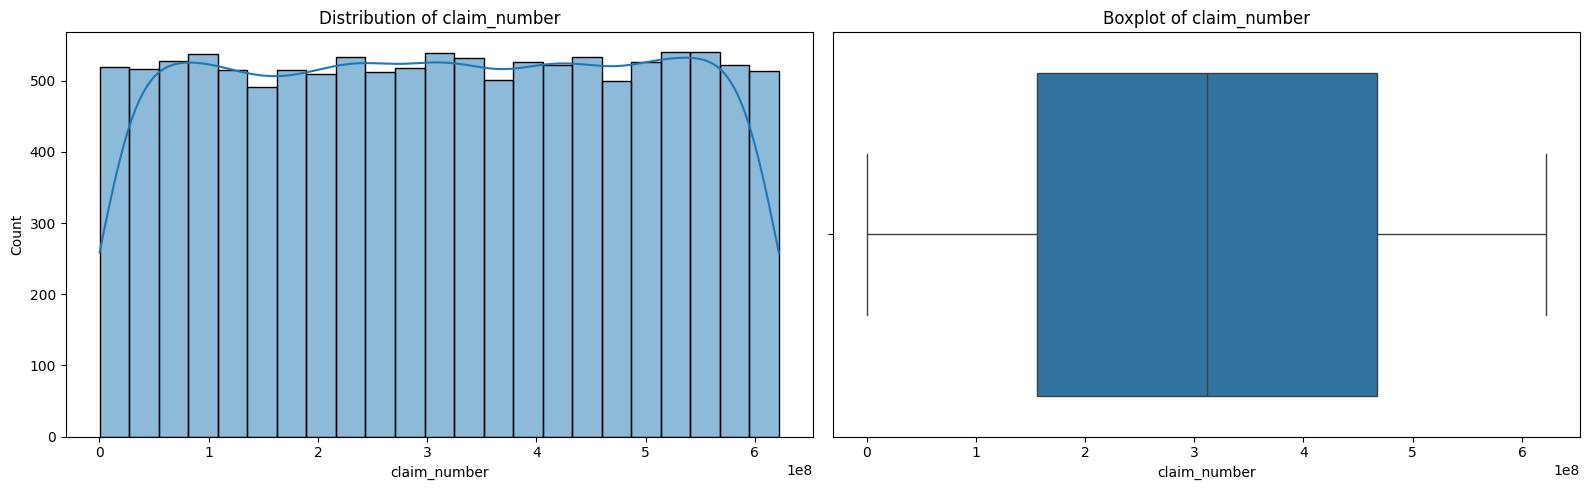

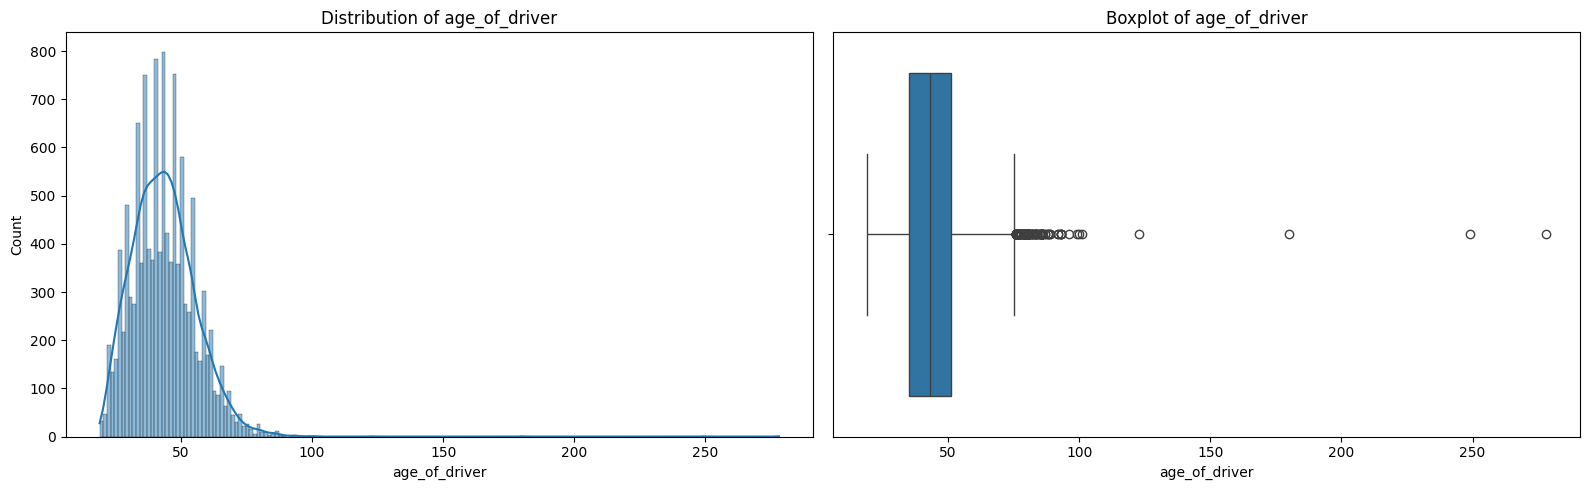

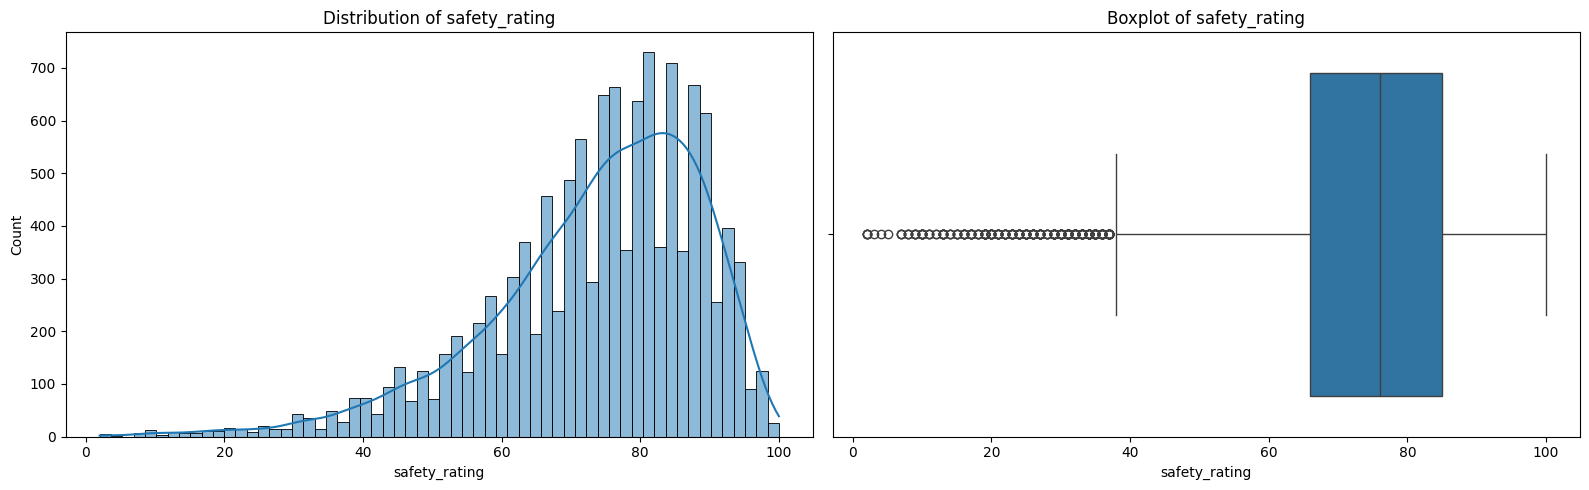

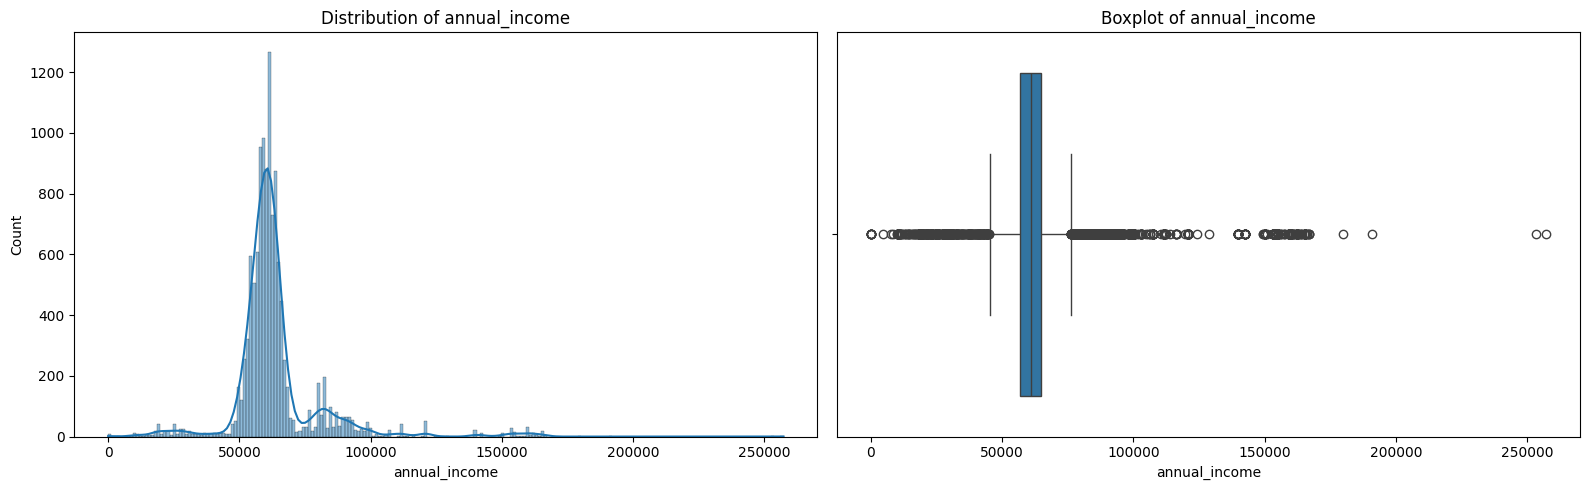

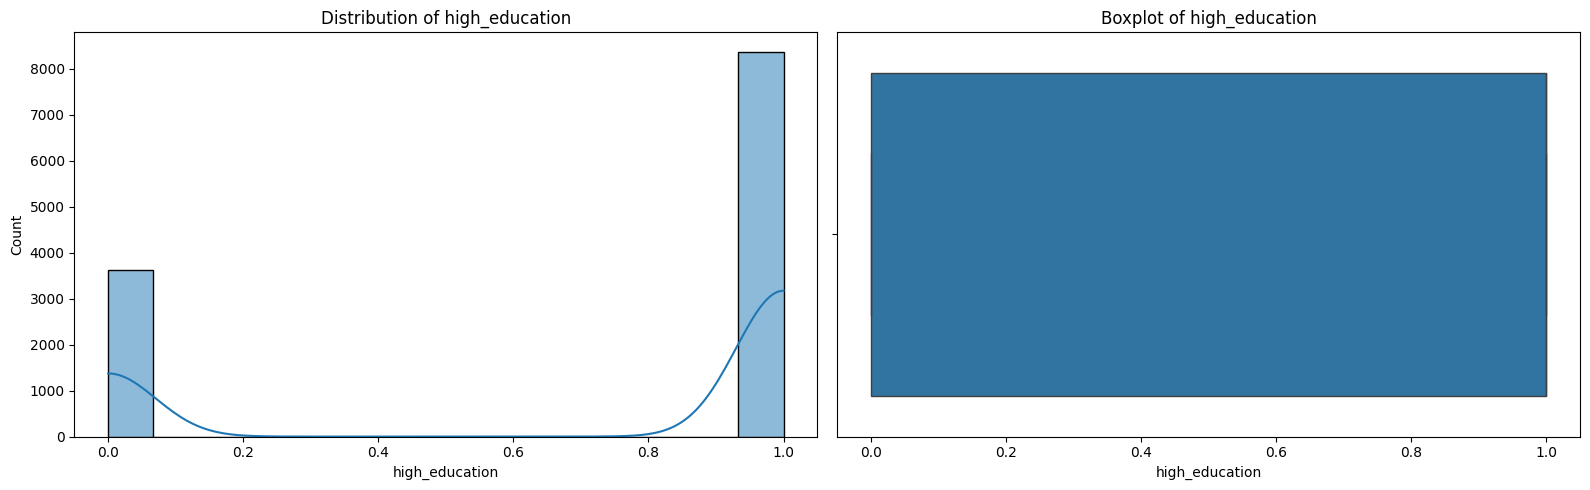

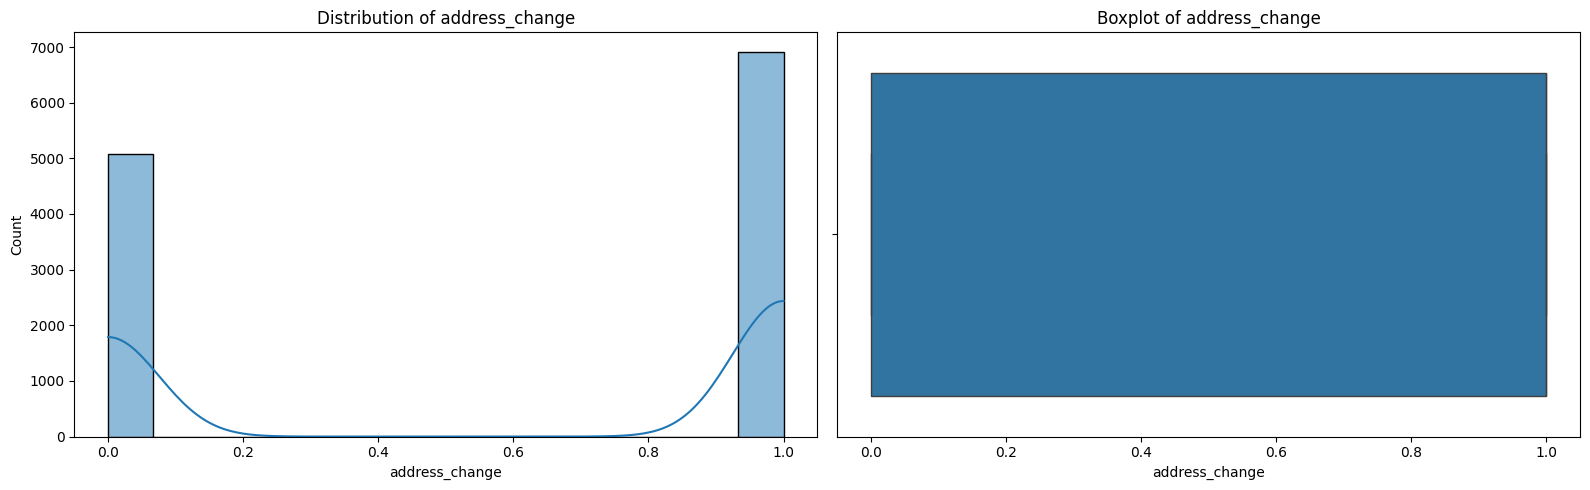

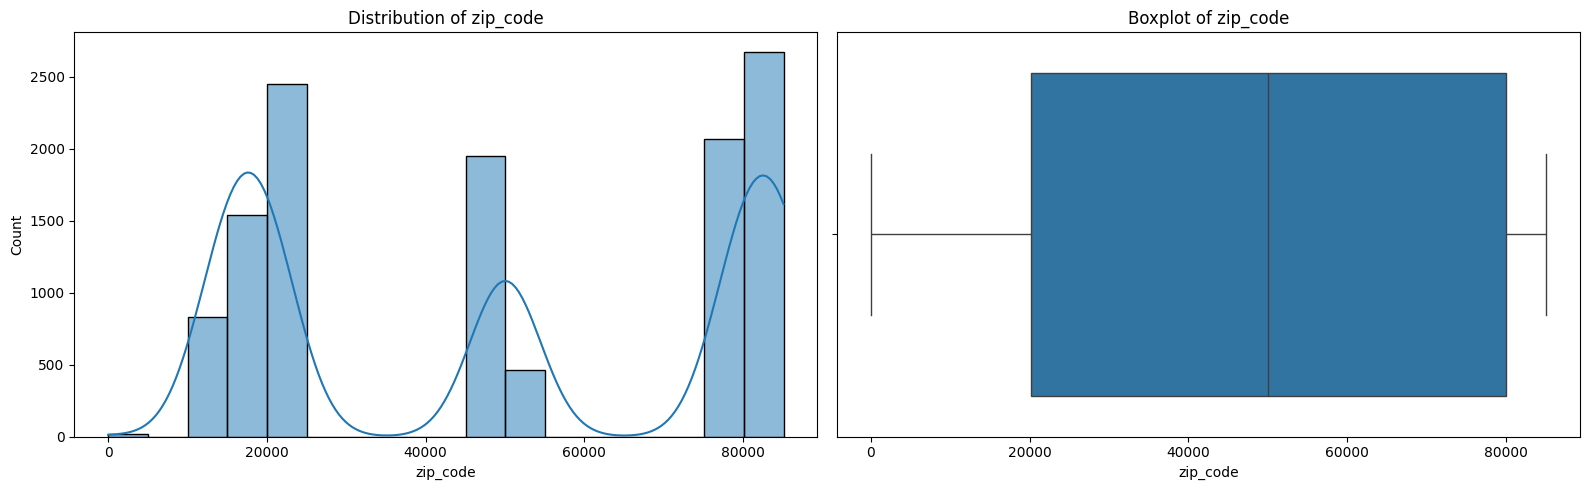

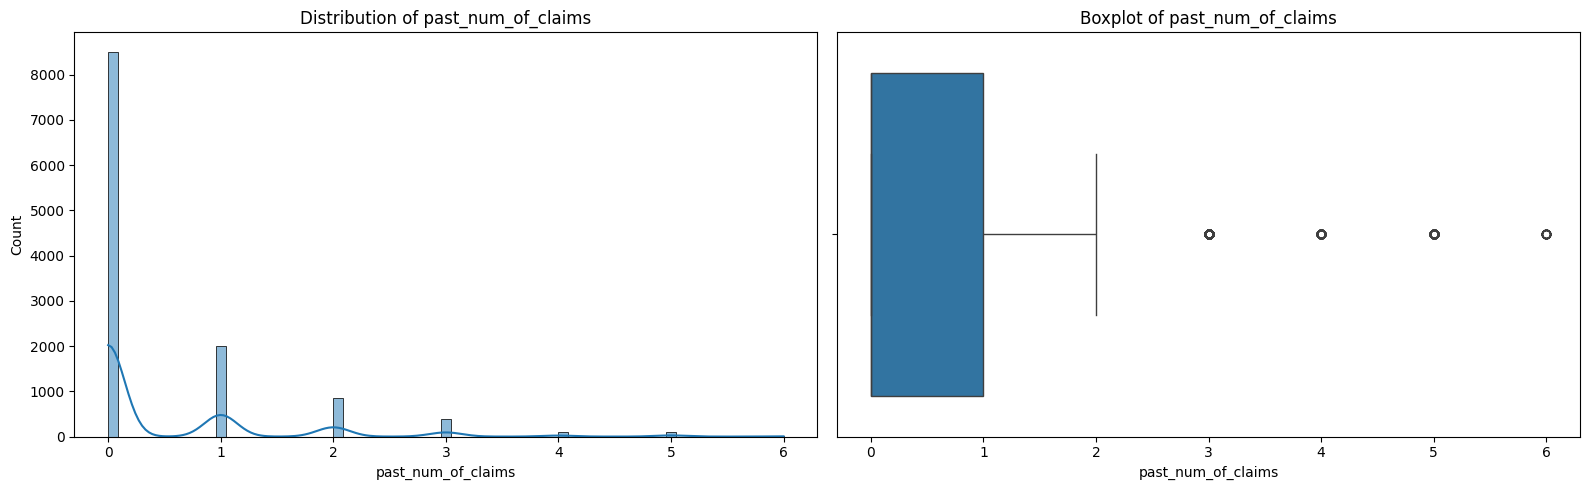

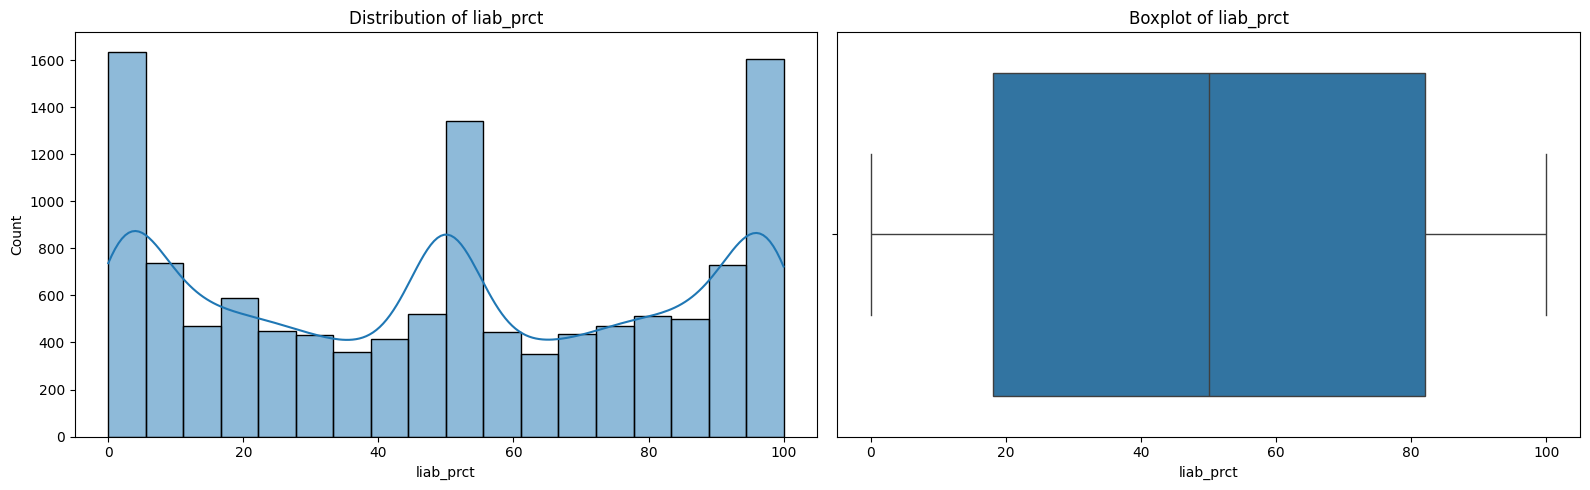

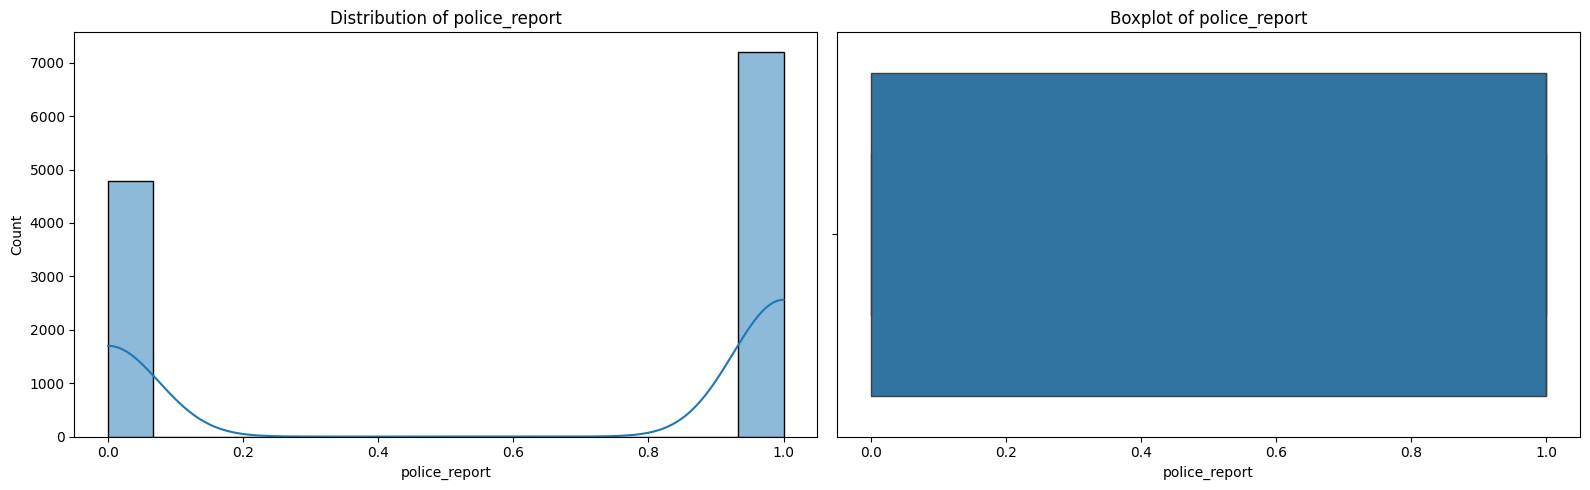

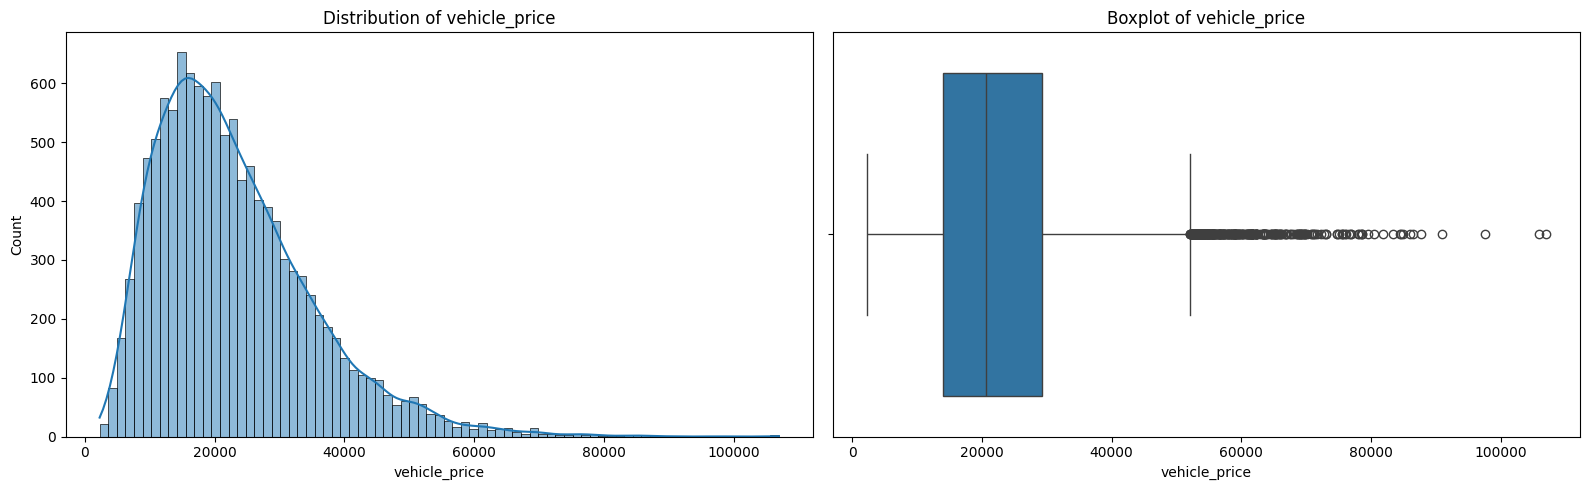

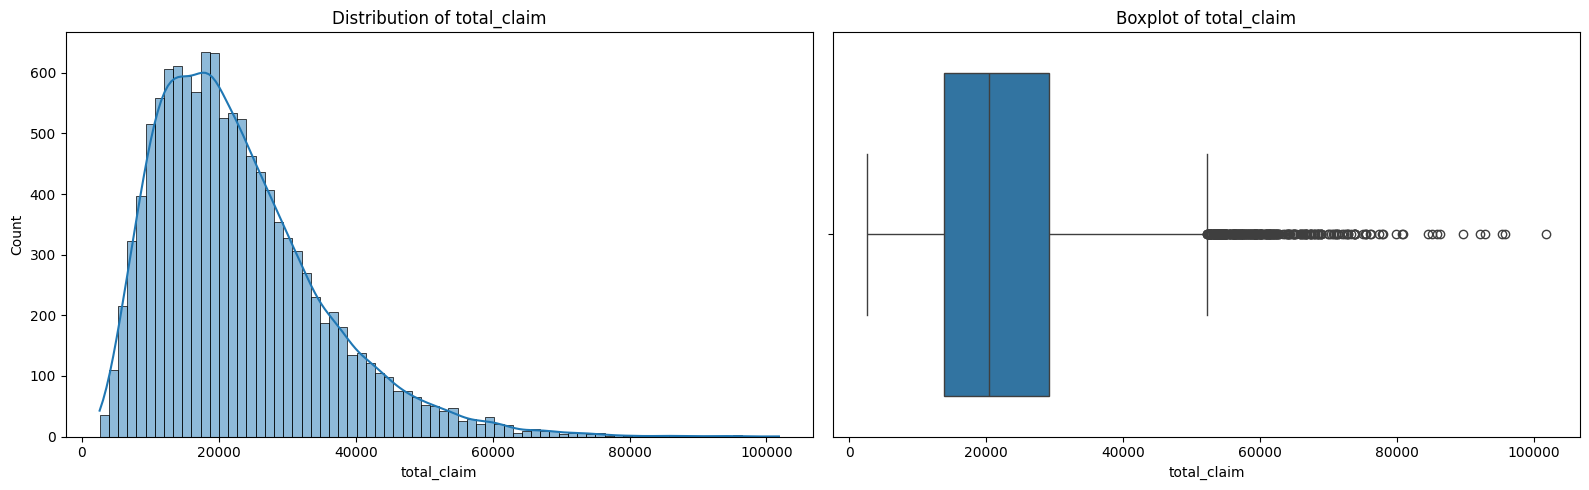

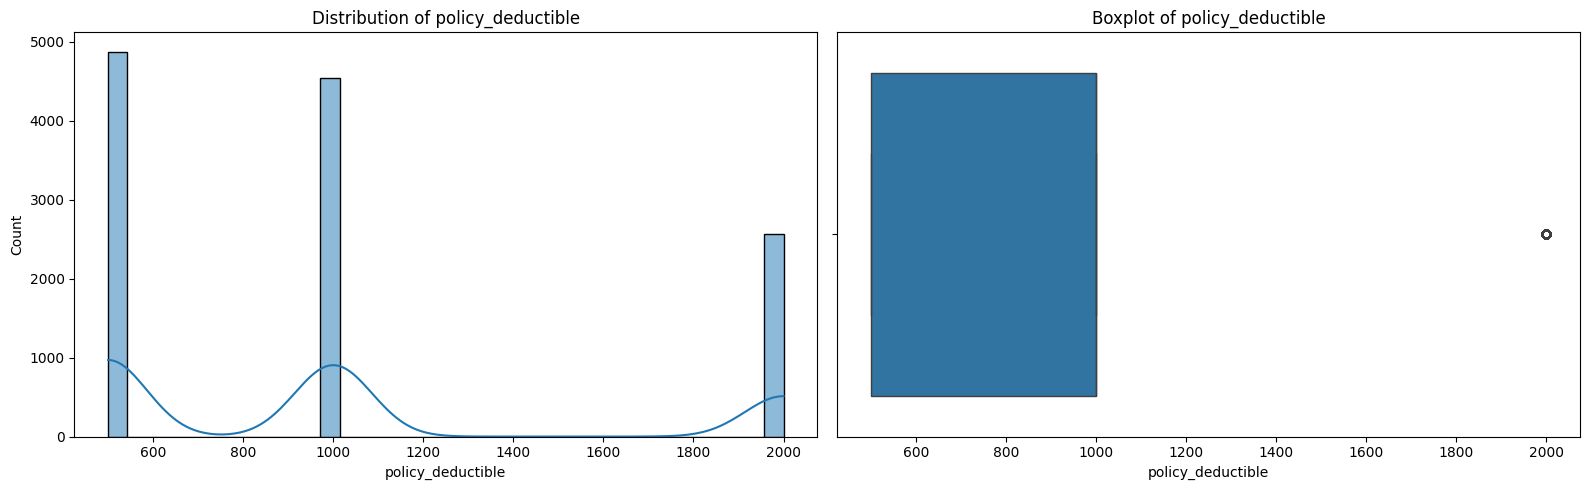

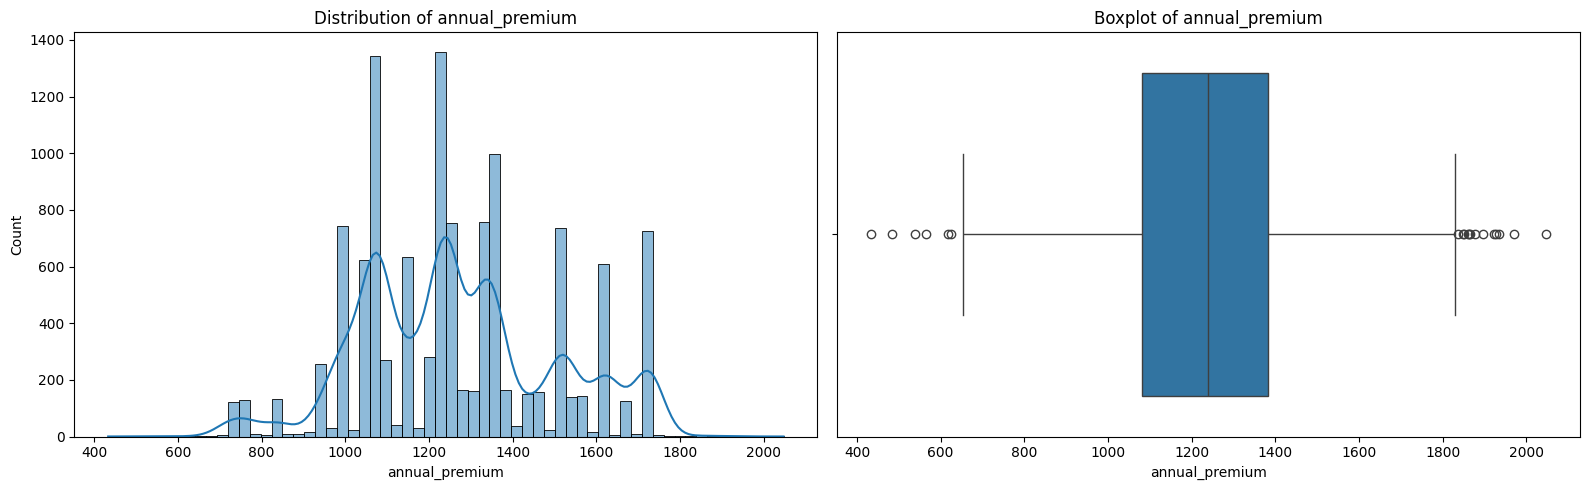

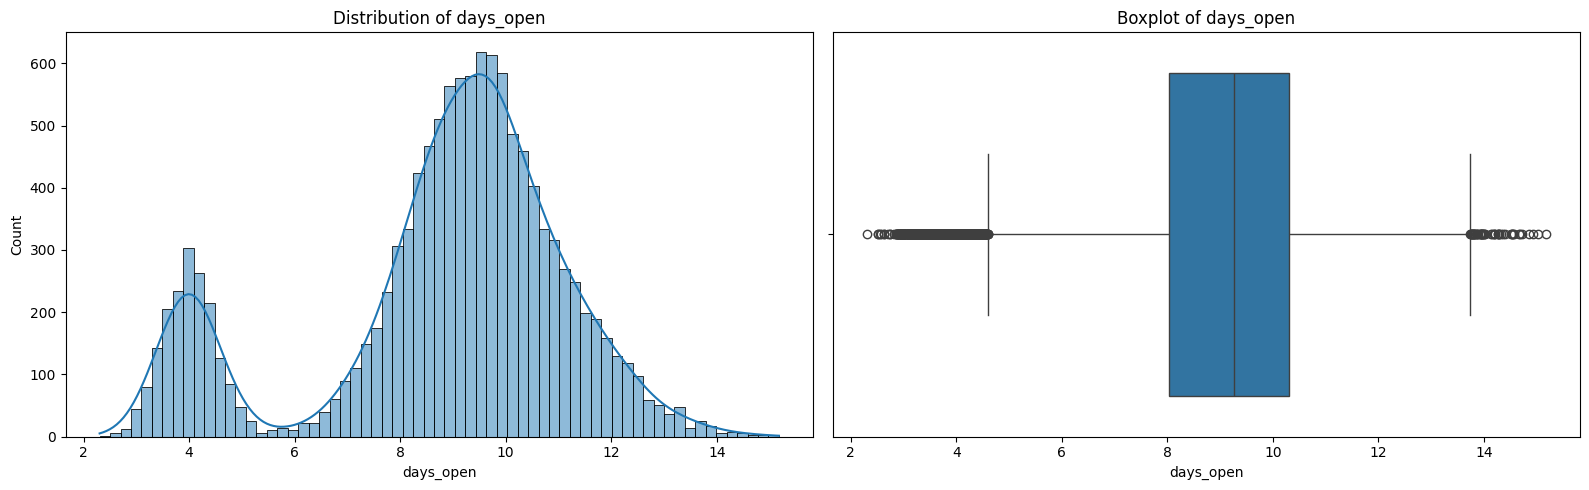

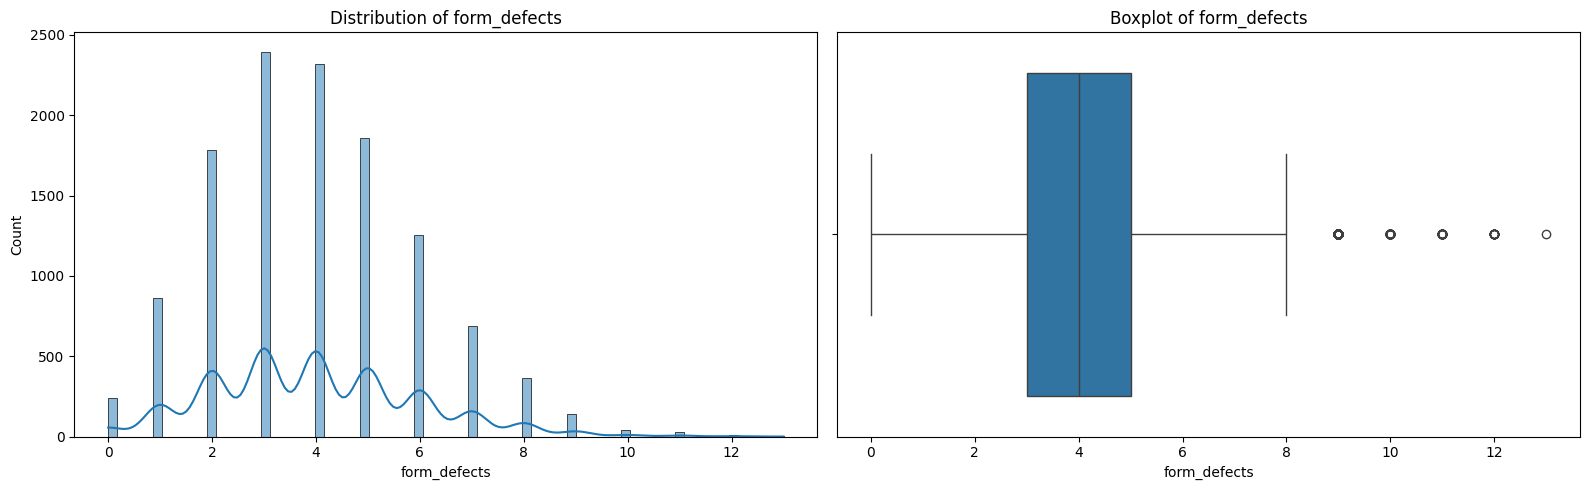

In [13]:
for col in Numerical_columns:
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(data=df, x=col, kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

### Claim_number is not required

### age_of_driver -> skwed -> Percentile method

In [14]:
ageQuantile = df["age_of_driver"].quantile(0.99)
df.shape

(11994, 29)

In [15]:
df = df[df["age_of_driver"] < ageQuantile]
df.shape

(11873, 29)

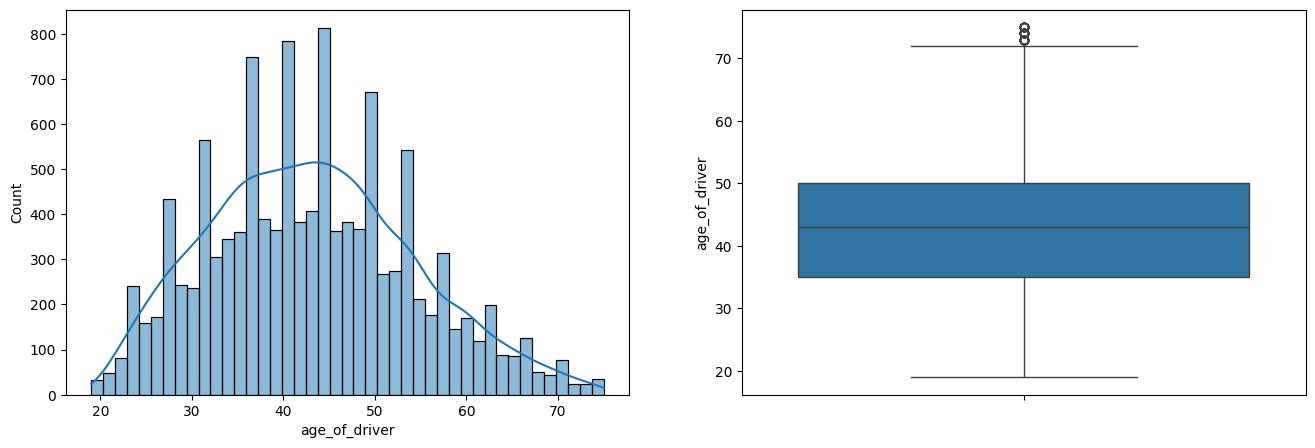

In [16]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x="age_of_driver", kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["age_of_driver"])
plt.show()

### safety_rating -> skwed -> percentile method

In [17]:
Q1 = df["safety_rating"].quantile(0.25)
Q3 = df["safety_rating"].quantile(0.75)
IQR = Q3 - Q1
lower_Bound = Q1 - 1.5 * IQR
upper_Bound = Q3 + 1.5 * IQR
df.shape

(11873, 29)

In [18]:
df = df[(df["safety_rating"] > lower_Bound) & (df["safety_rating"] < upper_Bound)]
df.shape

(11547, 29)

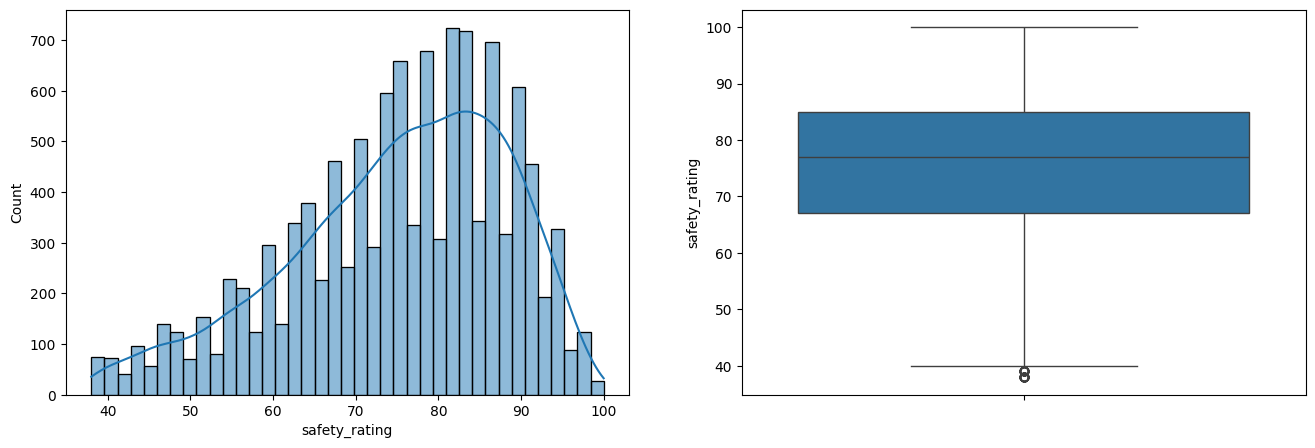

In [19]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x="safety_rating", kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["safety_rating"])
plt.show()

### annual_income 

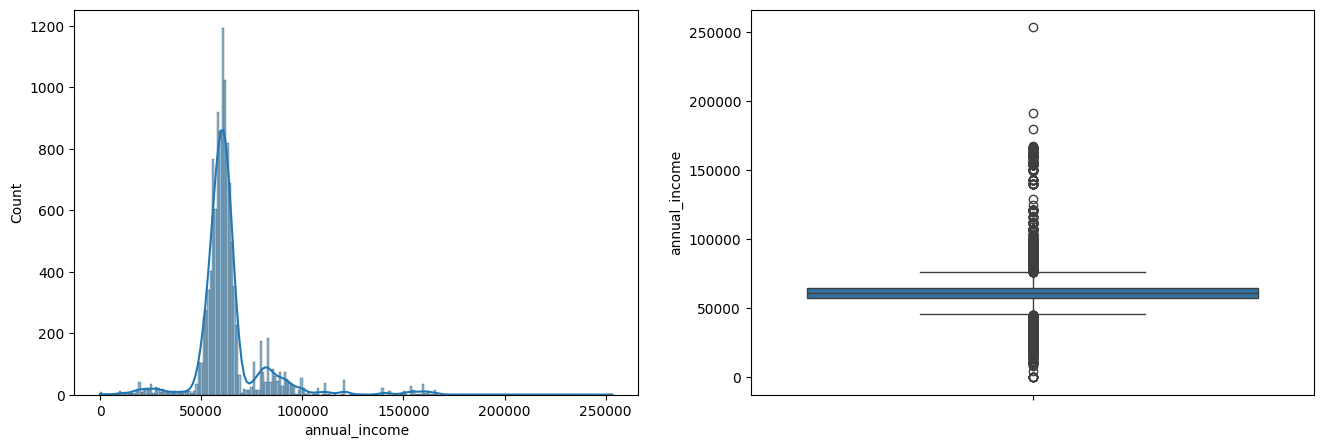

In [20]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x="annual_income", kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["annual_income"])
plt.show()

In [21]:
Q1 = df["annual_income"].quantile(0.20)
Q3 = df["annual_income"].quantile(0.80)
IQR = Q3 - Q1
lower_Bound = Q1 - 1.5 * IQR
upper_Bound = Q3 + 1.5 * IQR
df.shape

(11547, 29)

In [22]:
df = df[(df["annual_income"] > lower_Bound) & (df["annual_income"] < upper_Bound)]
df.shape

(9964, 29)

### high_education -> no outliers

### address_change -> no outliers

### zip_code -> no need 

### past_num_of_claims -> few outliears

### liab_prct -> no outliers

### police_report -> no outliears

### vehicle_price -> Skewed -> percentile

In [23]:
vehicle_price_Quantile = df["vehicle_price"].quantile(0.97)
df.shape

(9964, 29)

In [24]:
df = df[df["vehicle_price"] < vehicle_price_Quantile]
df.shape

(9665, 29)

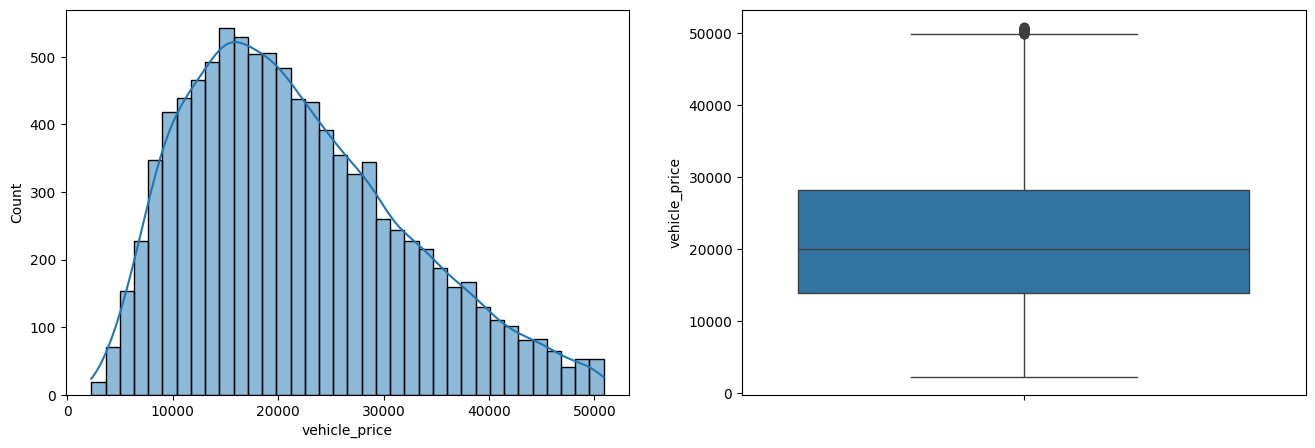

In [25]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x="vehicle_price", kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["vehicle_price"])
plt.show()

### total_claim -> skwed -> Percentile method

In [26]:
total_claim_Quantile = df["total_claim"].quantile(0.97)
df.shape

(9665, 29)

In [27]:
df = df[df["total_claim"] < total_claim_Quantile]
df.shape

(9375, 29)

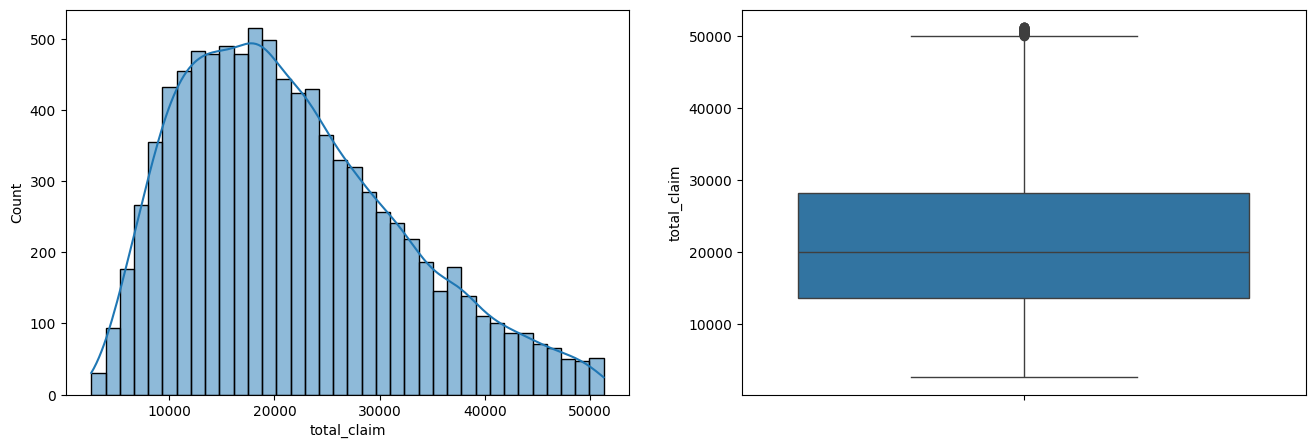

In [28]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x="total_claim", kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["total_claim"])
plt.show()

### annual_premium -> multi-peaked -> IQR

In [29]:
Q1 = df["annual_premium"].quantile(0.25)
Q3 = df["annual_premium"].quantile(0.75)
IQR = Q3 - Q1
lower_Bound = Q1 - 1.5 * IQR
upper_Bound = Q3 + 1.5 * IQR
df.shape

(9375, 29)

In [30]:
df = df[(df["annual_premium"] > lower_Bound) & (df["annual_premium"] < upper_Bound)]
df.shape

(9361, 29)

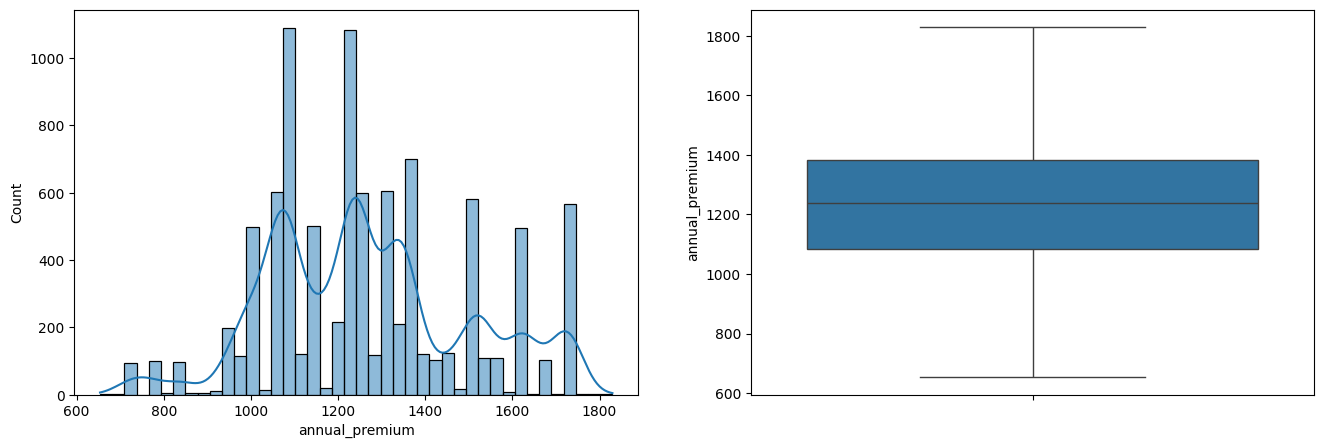

In [31]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x="annual_premium", kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["annual_premium"])
plt.show()

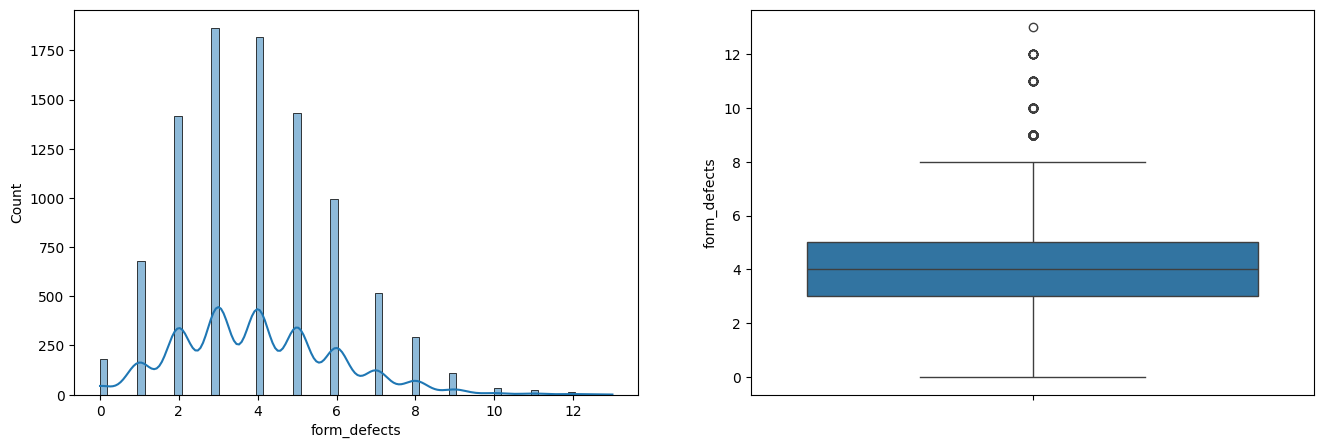

In [32]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x="form_defects", kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["form_defects"])
plt.show()

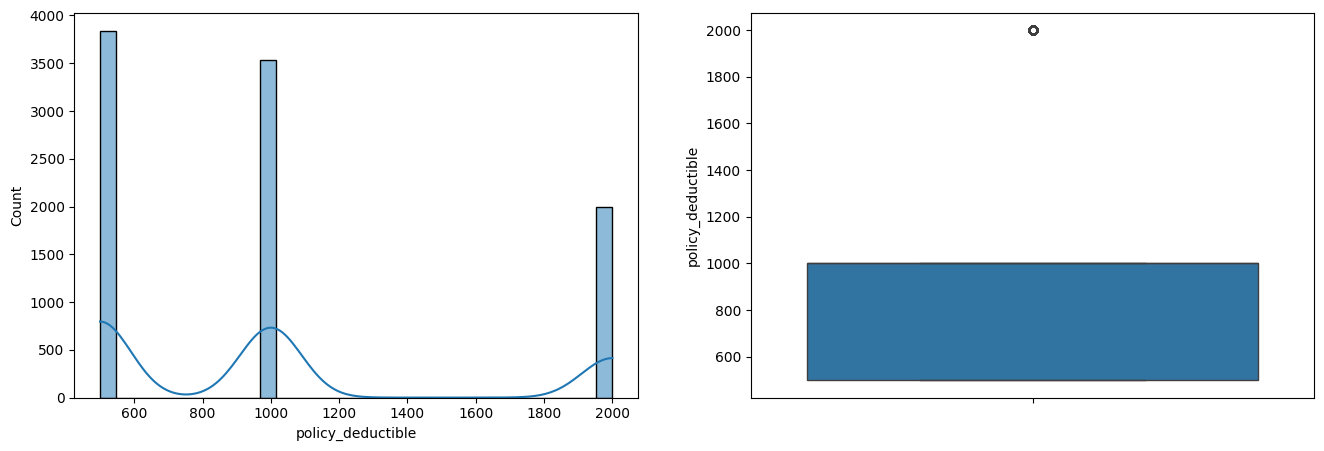

In [33]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x="policy_deductible", kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["policy_deductible"])
plt.show()

In [34]:
Q1 = df["days_open"].quantile(0.22)
Q3 = df["days_open"].quantile(0.78)
IQR = Q3 - Q1
lower_Bound = Q1 - 1.5 * IQR
upper_Bound = Q3 + 1.5 * IQR
df.shape

(9361, 29)

In [35]:
df = df[(df["days_open"] > lower_Bound) & (df["days_open"] < upper_Bound)]
df.shape

(8993, 29)

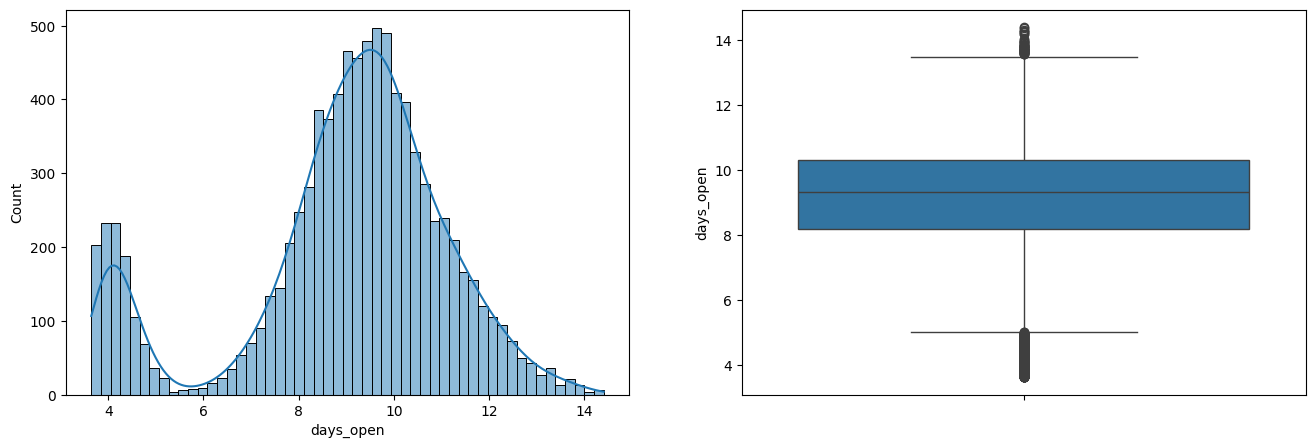

In [36]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x="days_open", kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["days_open"])
plt.show()

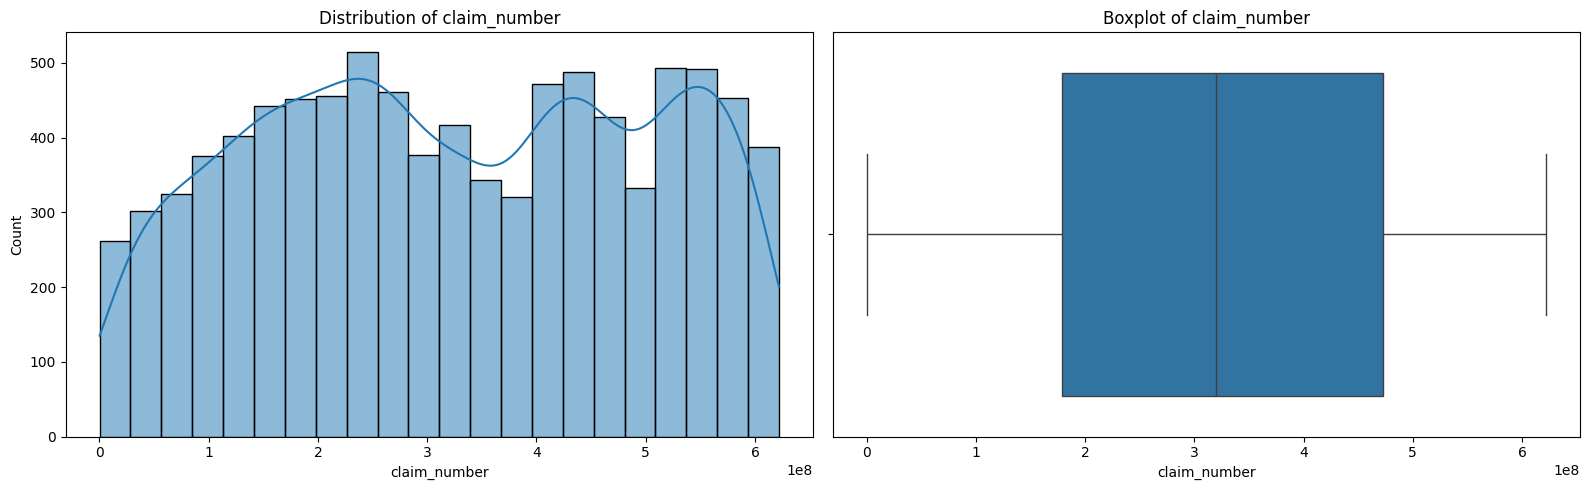

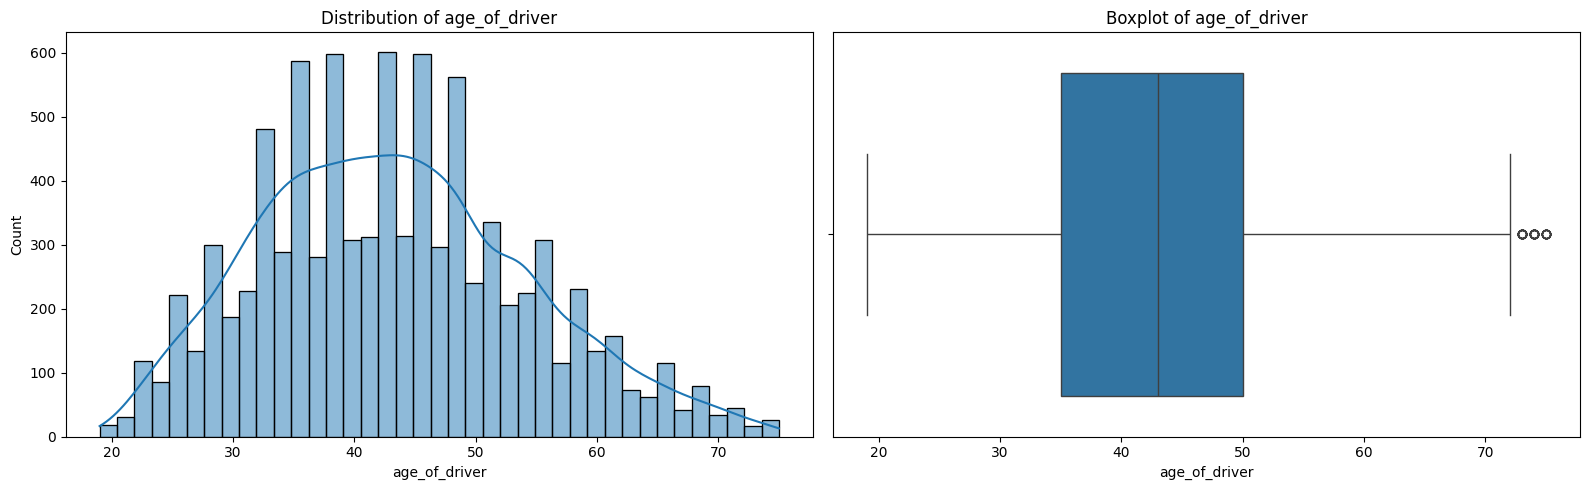

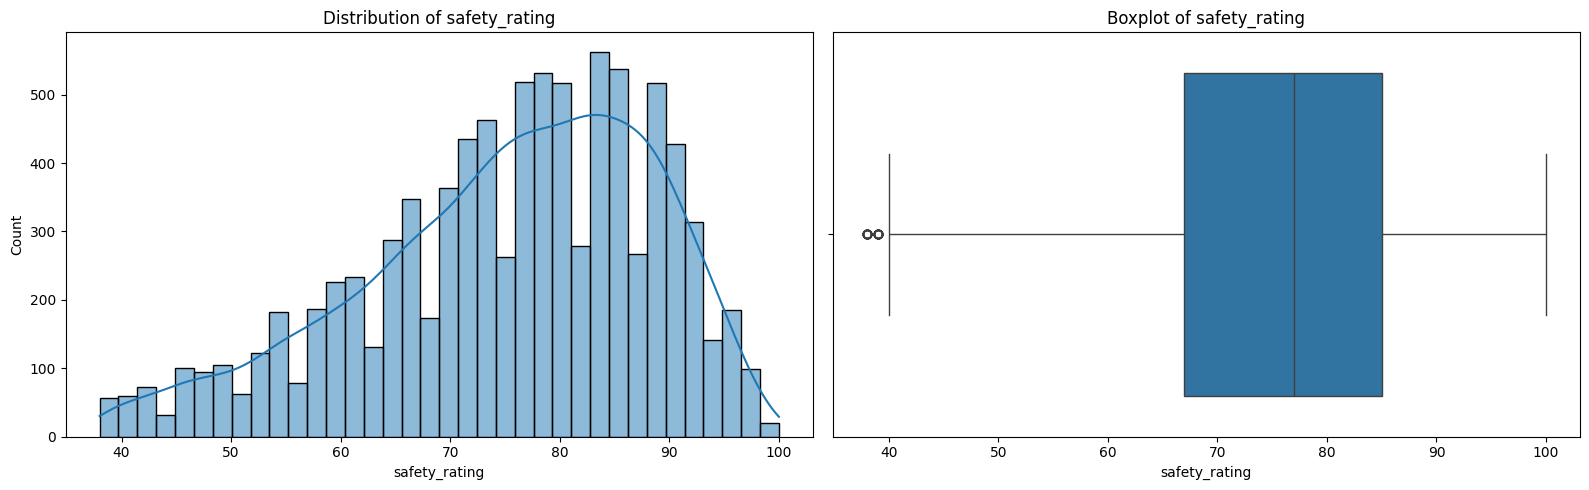

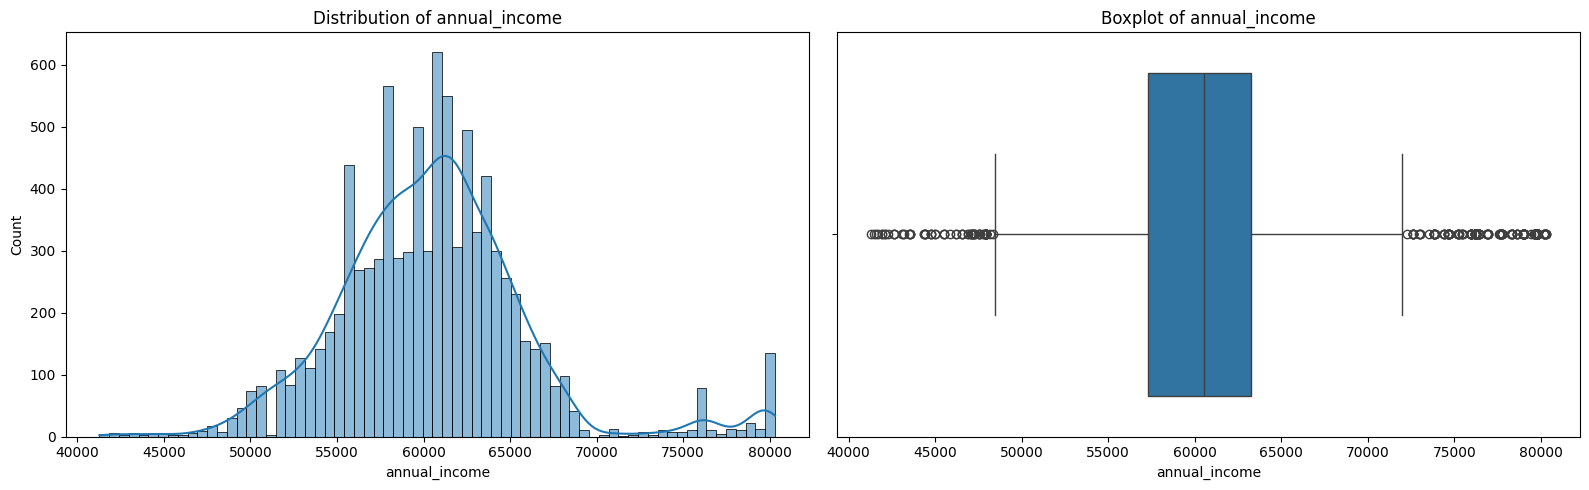

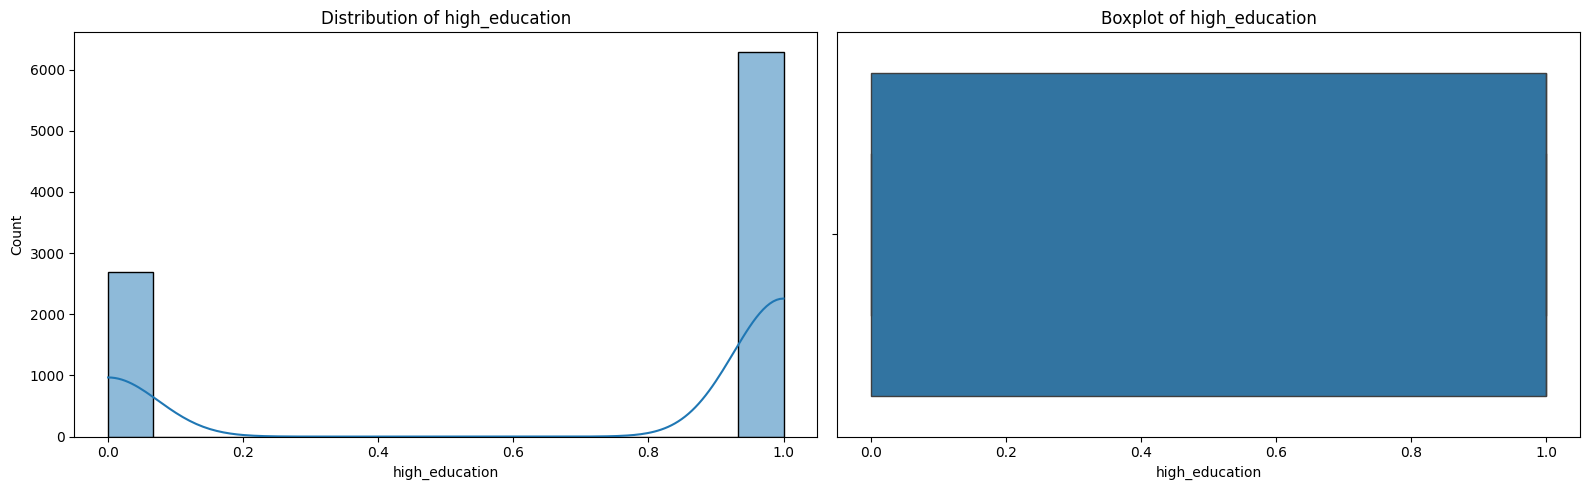

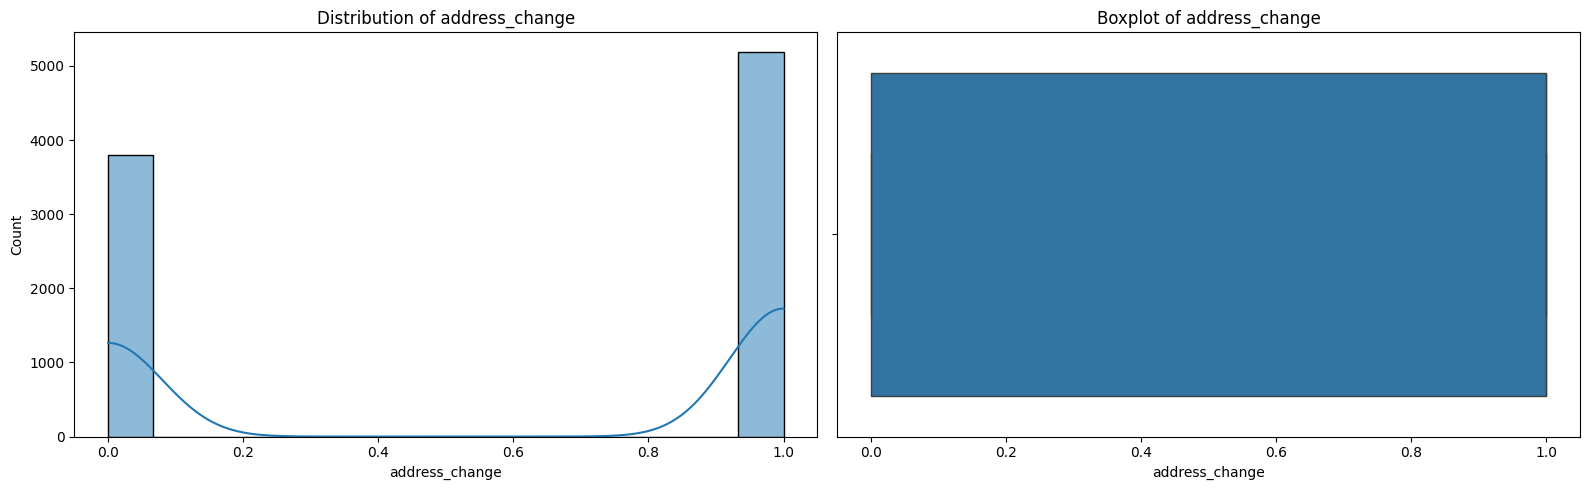

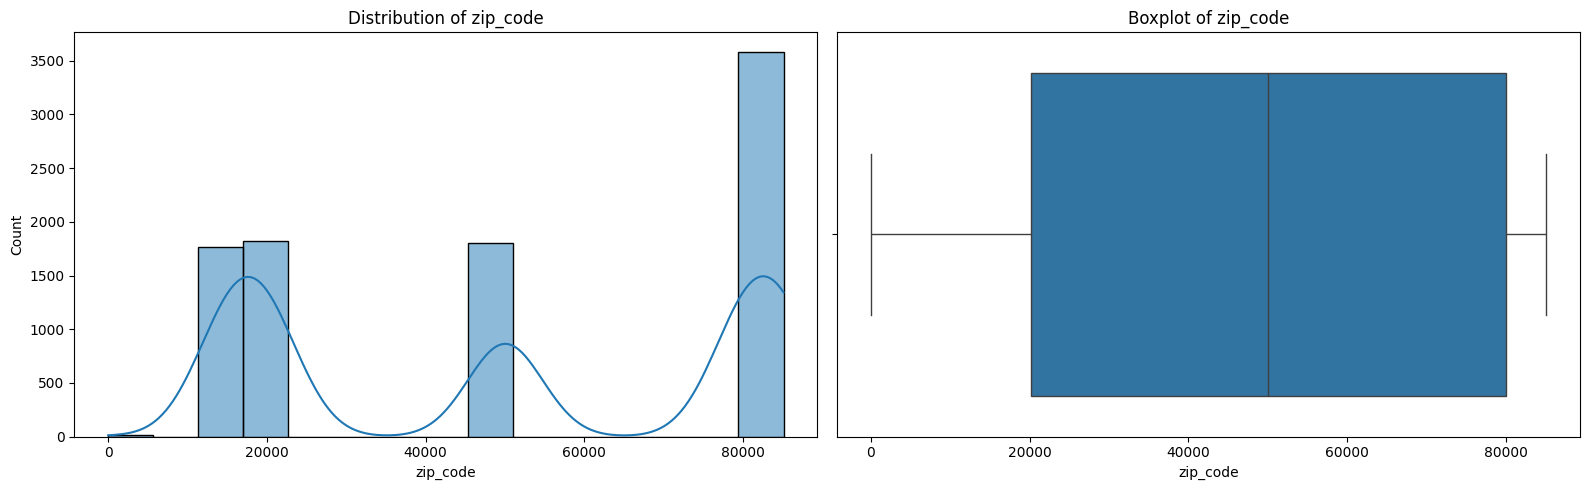

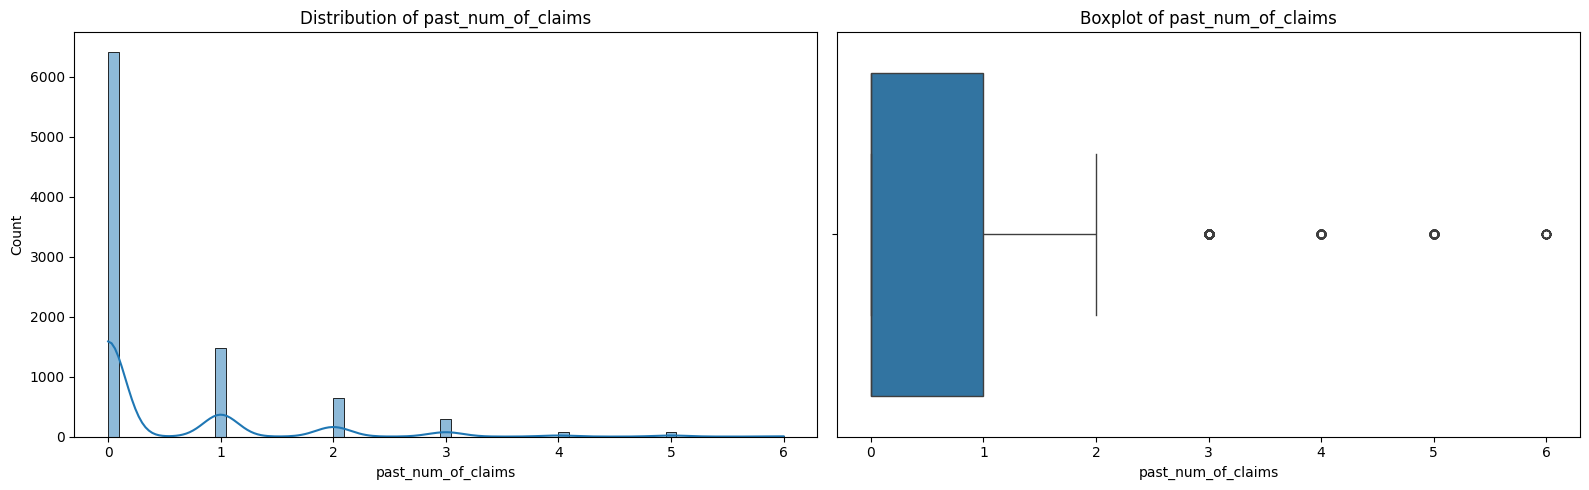

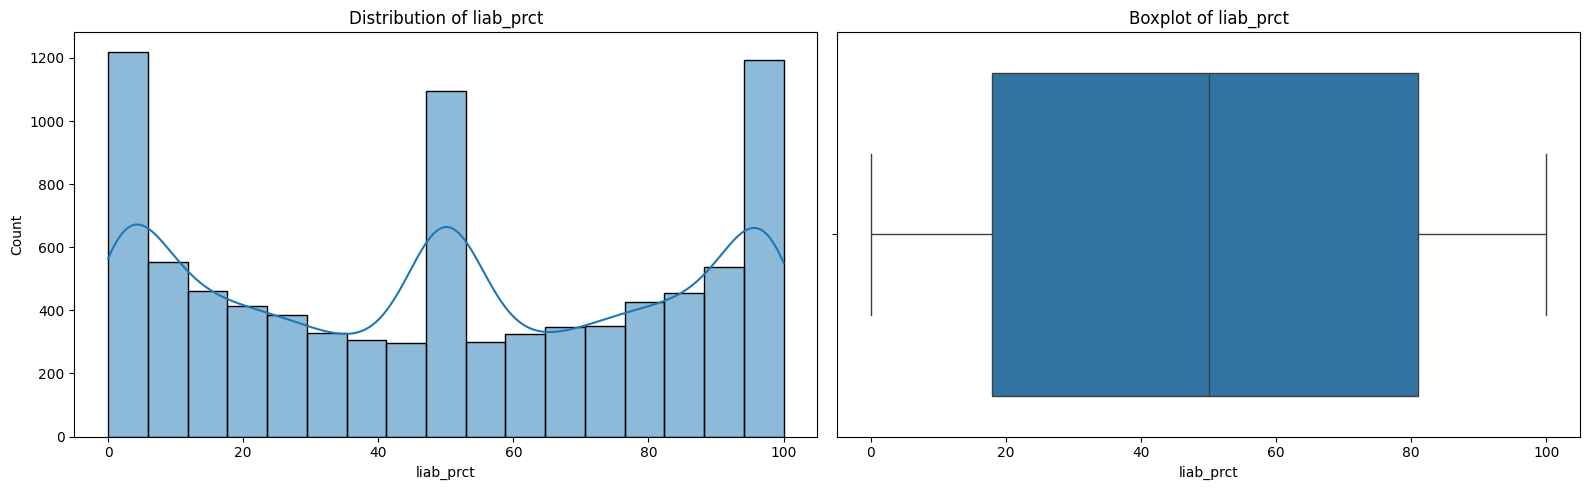

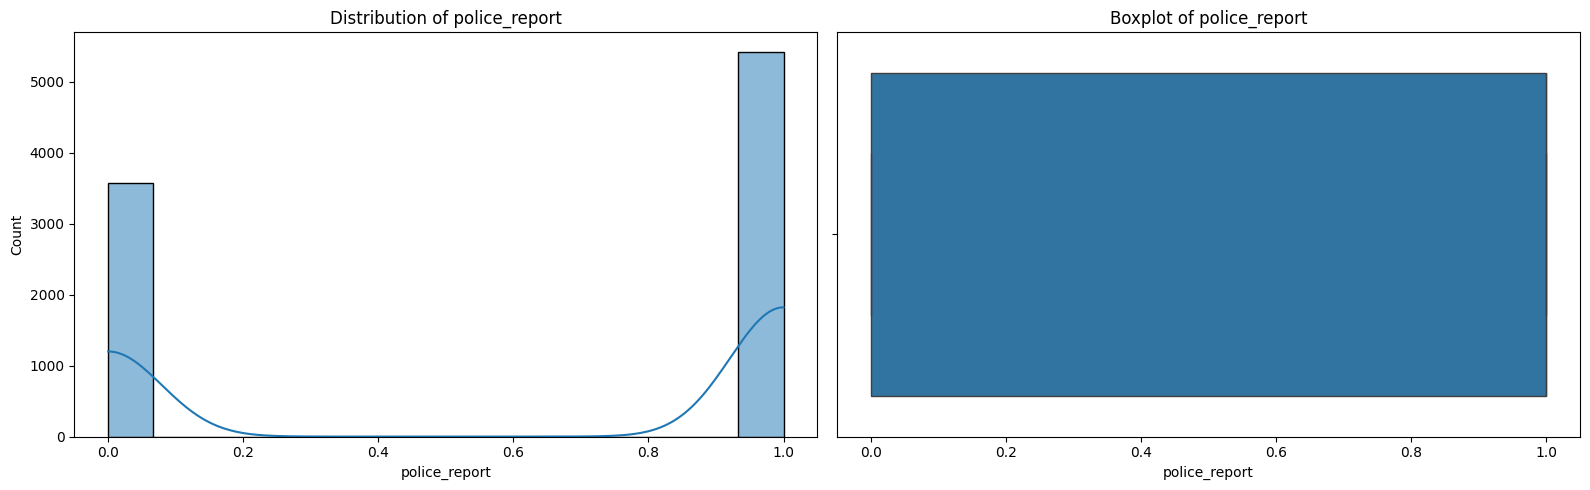

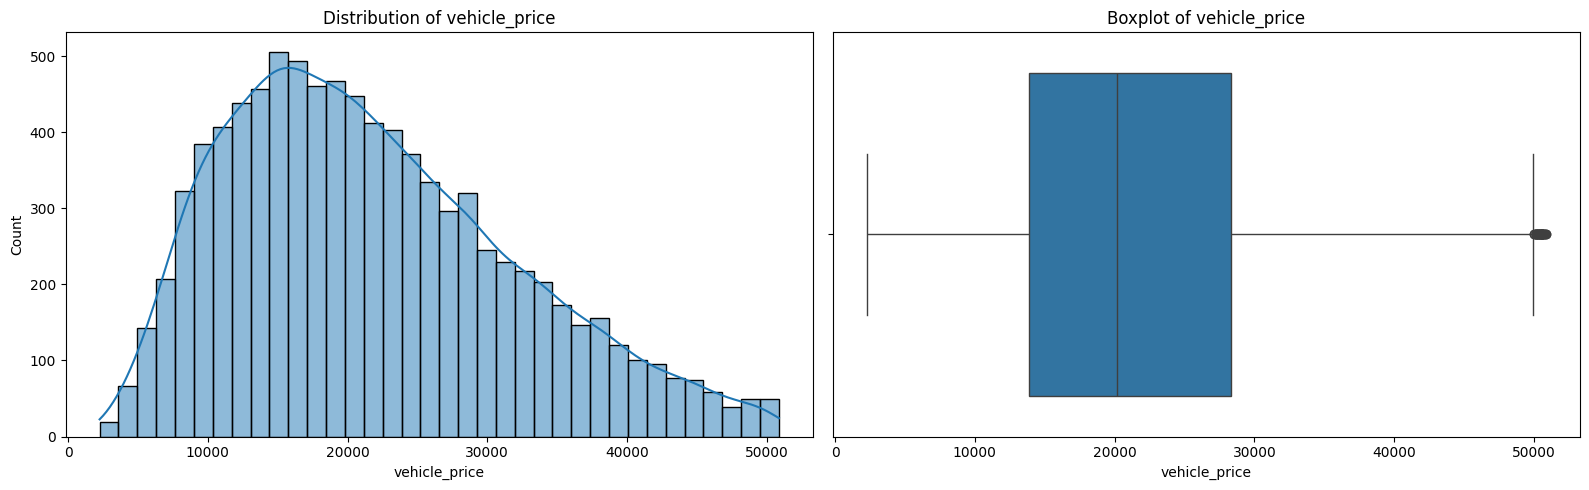

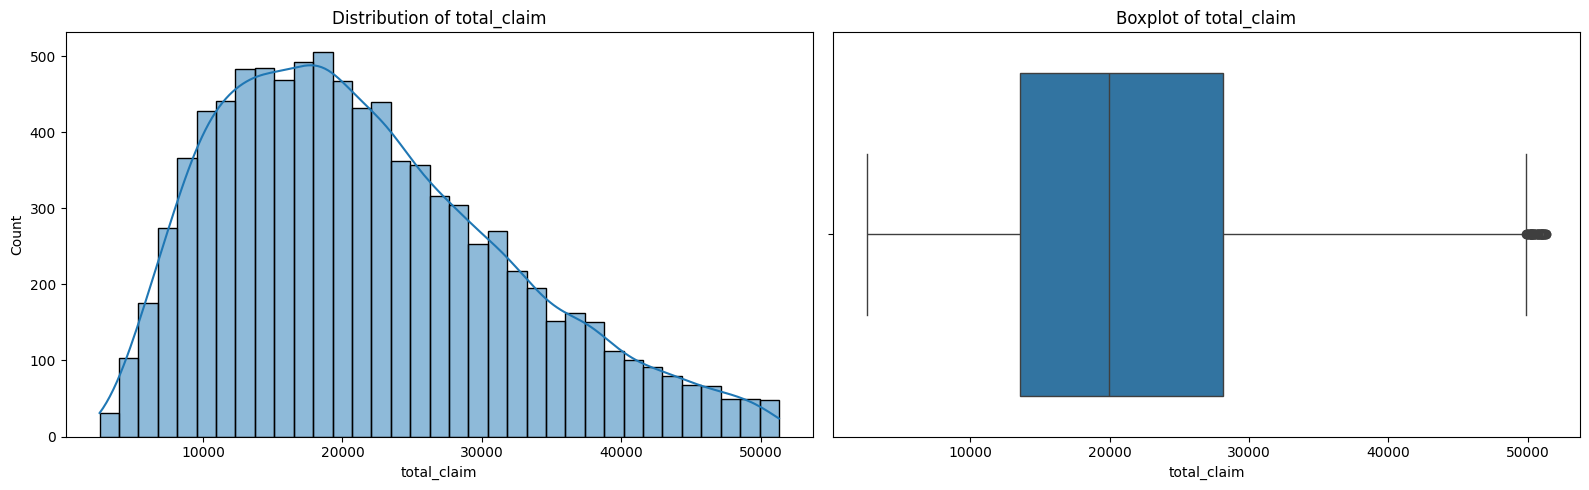

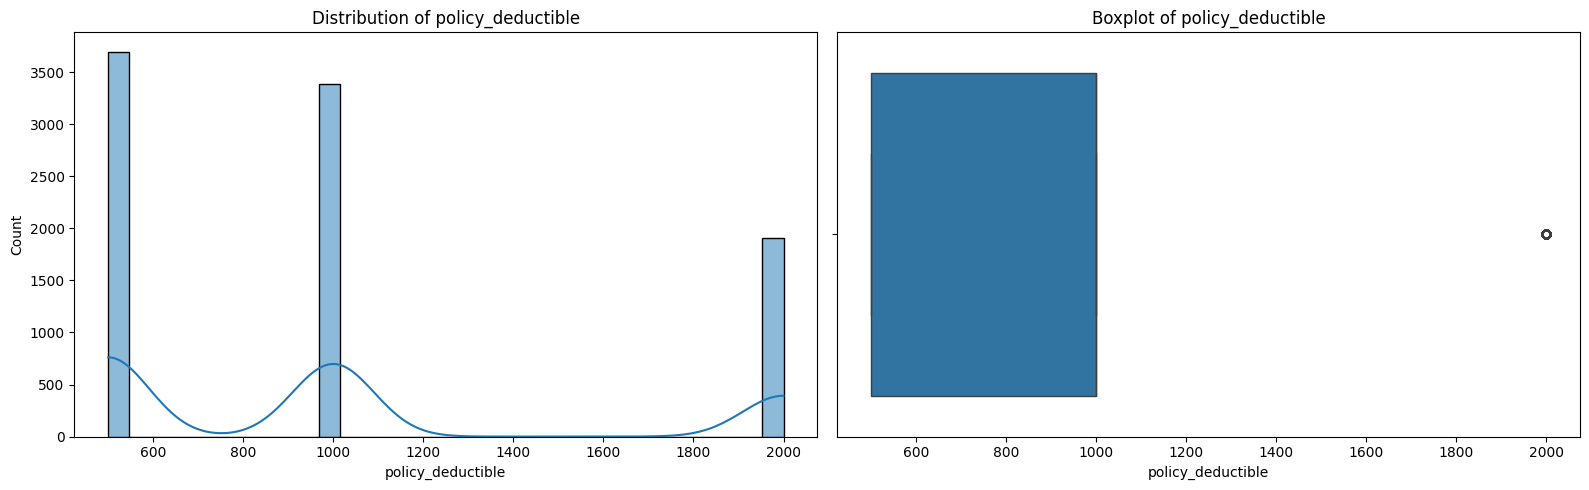

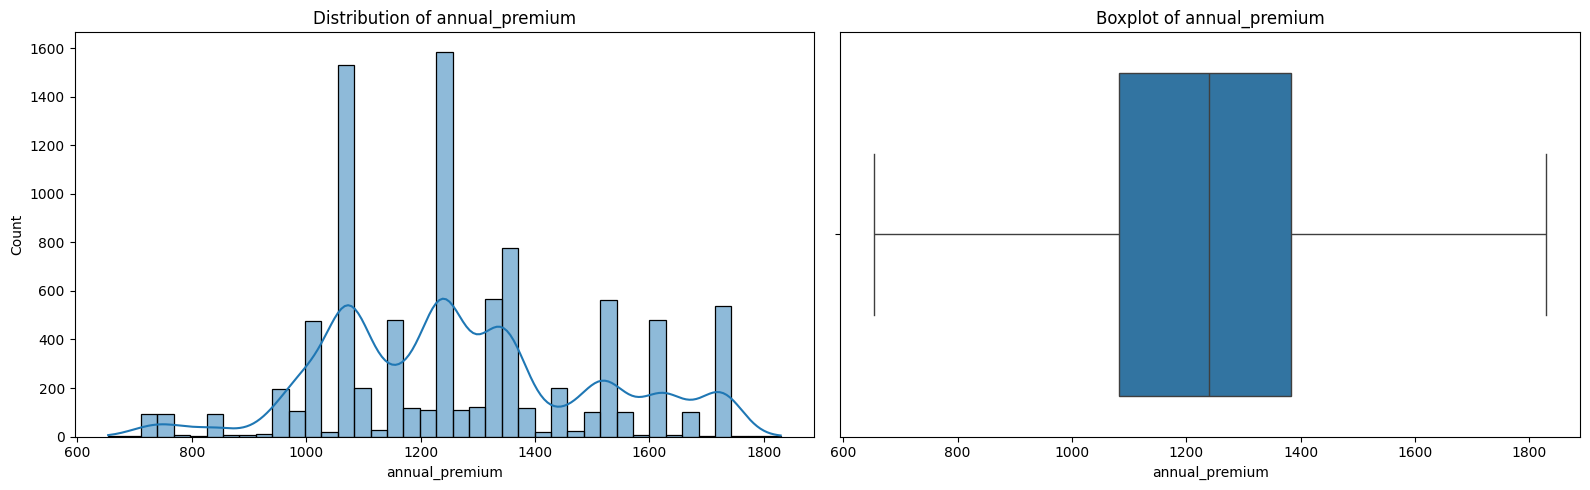

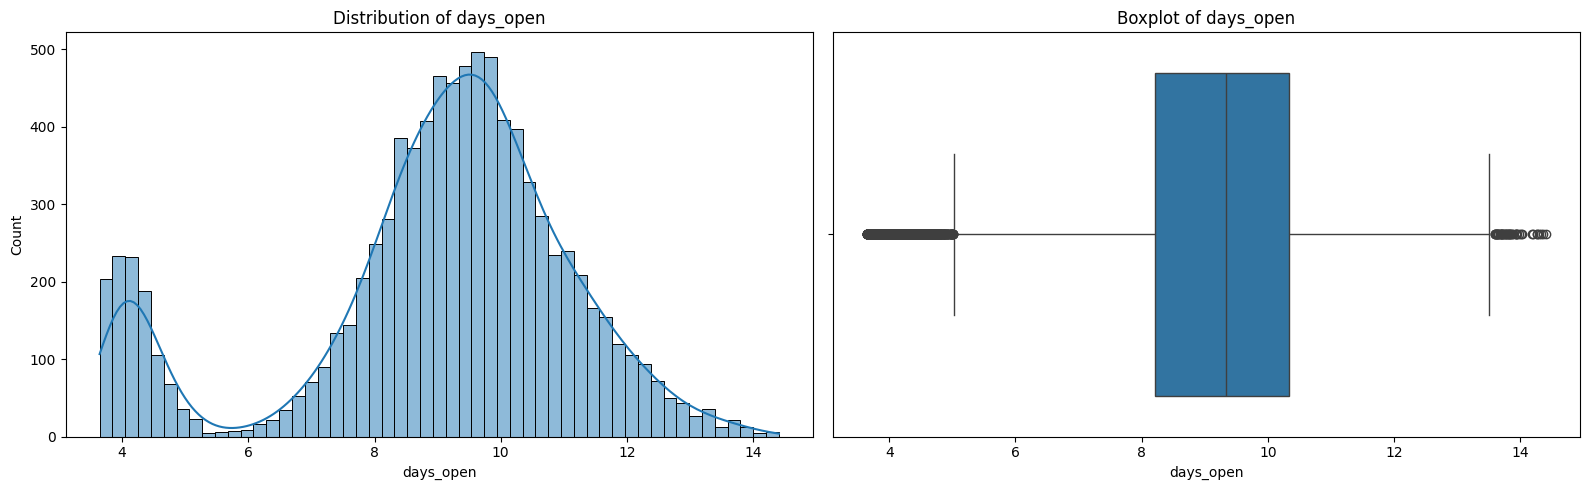

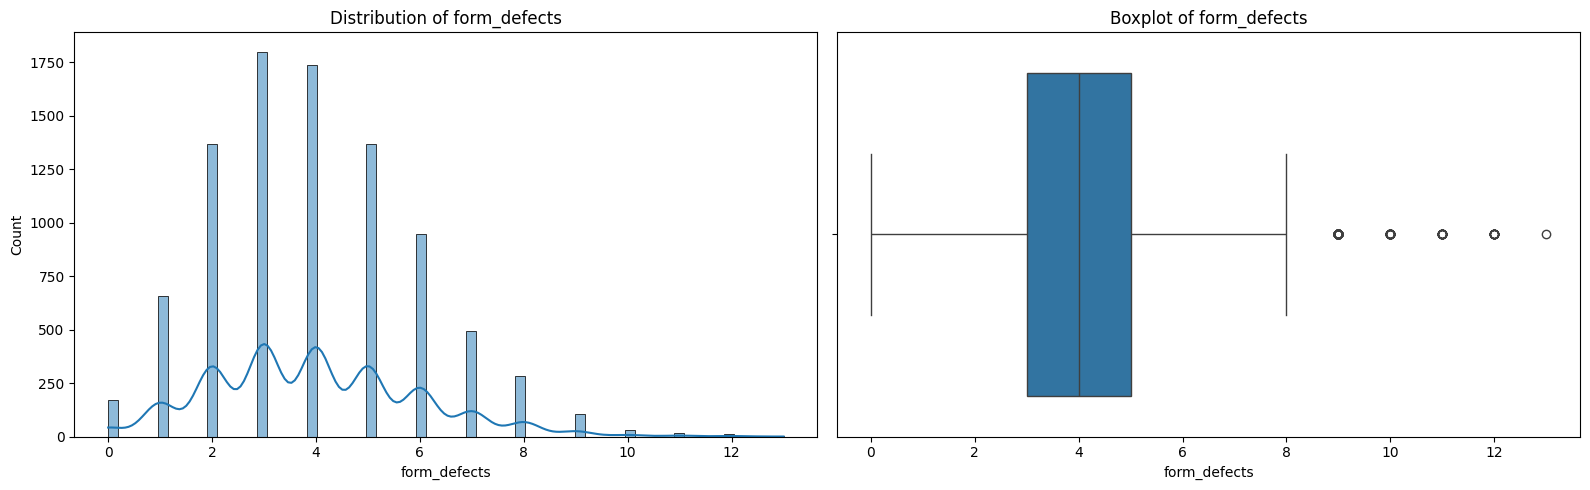

In [37]:
for col in Numerical_columns:
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(data=df, x=col, kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

## 2. Categorical Encoding

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8993 entries, 0 to 12001
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   claim_number        8993 non-null   int64  
 1   age_of_driver       8993 non-null   int64  
 2   gender              8993 non-null   object 
 3   marital_status      8993 non-null   object 
 4   safety_rating       8993 non-null   int64  
 5   annual_income       8993 non-null   float64
 6   high_education      8993 non-null   int64  
 7   address_change      8993 non-null   int64  
 8   property_status     8993 non-null   object 
 9   zip_code            8993 non-null   int64  
 10  claim_date          8993 non-null   object 
 11  claim_day_of_week   8993 non-null   object 
 12  accident_site       8993 non-null   object 
 13  past_num_of_claims  8993 non-null   int64  
 14  witness_present     8993 non-null   object 
 15  liab_prct           8993 non-null   int64  
 16  channel   

In [39]:
df["marital_status"].value_counts()
#claim_date -> int64 -> datetime -> Done
#marital_status -> int64
#witness_present -> int64
#age_of_vehicle -> int64
#injury_claim -> float64
#fraud_reported -> LabelEncoder

marital_status
1    6429
0    2562
*       2
Name: count, dtype: int64

In [40]:
# df["claim_date"] = pd.to_datetime(df["claim_date"])
df["claim_date"] = pd.to_datetime(
    df["claim_date"],
    format="%m/%d/%Y",
    errors="coerce"
)


df["claim_year"] = df["claim_date"].dt.year
df["claim_month"] = df["claim_date"].dt.month
df["claim_day"] = df["claim_date"].dt.day

df.drop("claim_date", axis=1, inplace=True)

In [41]:
df["witness_present"] = df["witness_present"].replace('*' , np.nan)
df["witness_present"] = df["witness_present"].fillna("0")
df["witness_present"] = pd.to_numeric(df["witness_present"])
df["witness_present"].dtype

dtype('int64')

In [42]:
df["age_of_vehicle"] = df["age_of_vehicle"].replace("*" , np.nan)
df.dropna(inplace=True)
df["age_of_vehicle"] = pd.to_numeric(df["age_of_vehicle"])
df["age_of_vehicle"].dtype

dtype('int64')

In [43]:
df["injury_claim"] = df["injury_claim"].replace("*" , np.nan)
df.dropna(inplace=True)
df["injury_claim"] = pd.to_numeric(df["injury_claim"])
df["injury_claim"].dtype

dtype('float64')

In [44]:
df["marital_status"] = df["marital_status"].replace("*" , np.nan)
df.dropna(inplace=True)
df["marital_status"] = pd.to_numeric(df["marital_status"])
df["marital_status"].dtype

dtype('int64')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8967 entries, 0 to 12001
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   claim_number        8967 non-null   int64  
 1   age_of_driver       8967 non-null   int64  
 2   gender              8967 non-null   object 
 3   marital_status      8967 non-null   int64  
 4   safety_rating       8967 non-null   int64  
 5   annual_income       8967 non-null   float64
 6   high_education      8967 non-null   int64  
 7   address_change      8967 non-null   int64  
 8   property_status     8967 non-null   object 
 9   zip_code            8967 non-null   int64  
 10  claim_day_of_week   8967 non-null   object 
 11  accident_site       8967 non-null   object 
 12  past_num_of_claims  8967 non-null   int64  
 13  witness_present     8967 non-null   int64  
 14  liab_prct           8967 non-null   int64  
 15  channel             8967 non-null   object 
 16  police_rep

In [46]:
df.shape

(8967, 31)

In [47]:
df.isnull().sum().sum()

np.int64(0)

In [48]:
df1 = df.iloc[: , :27]
df1.sample()

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,age_of_vehicle,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy_deductible,annual_premium,days_open,form_defects
4455,221107968,45,F,0,65,60908.8,1,0,Own,20113,...,4,Medium,15623.41446,gray,10395.77693,2336.513747,500,1564.43,4.247775,4


In [49]:
df2 = df.iloc[: , 28:]
df2.sample()

,claim_year,claim_month,claim_day
10557,2024.0,11.0,6.0


In [50]:
x = pd.concat([df1 , df2] , axis=1)
x.isnull().sum()

claim_number          0
age_of_driver         0
gender                0
marital_status        0
safety_rating         0
annual_income         0
high_education        0
address_change        0
property_status       0
zip_code              0
claim_day_of_week     0
accident_site         0
past_num_of_claims    0
witness_present       0
liab_prct             0
channel               0
police_report         0
age_of_vehicle        0
vehicle_category      0
vehicle_price         0
vehicle_color         0
total_claim           0
injury_claim          0
policy_deductible     0
annual_premium        0
days_open             0
form_defects          0
claim_year            0
claim_month           0
claim_day             0
dtype: int64

In [51]:
y = df.iloc[: , 27]
y.sample()
# y.isnull().sum()

7720    N
Name: fraud_reported, dtype: object

In [52]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2)

In [53]:
categorical_columns = df.columns[df.dtypes == "object"]
categorical_columns

Index(['gender', 'property_status', 'claim_day_of_week', 'accident_site',
       'channel', 'vehicle_category', 'vehicle_color', 'fraud_reported'],
      dtype='object')

In [54]:
# Gender -> one-hot
# property_status -> one-hot
# claim_day_of_week -> one-hot
# accidental_site -> one-hot
# channel -> one-hot
# vehicle_category -> ordinal
# vehicle_color -> one-hot
# fraud_reported -> Label

In [55]:
x_train

,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_color,total_claim,injury_claim,policy_deductible,annual_premium,days_open,form_defects,claim_year,claim_month,claim_day
1731,277240320,45,M,1,87,60912.0,1,0,Rent,20102,...,blue,13886.61306,4847.362712,500,1082.36,8.437714,5,2023.0,8.0,2.0
5889,23825664,38,M,0,91,58196.8,1,1,Own,20110,...,gray,12981.59998,2422.656745,500,1008.38,8.914605,5,2023.0,1.0,25.0
11645,588052224,42,M,1,67,79776.0,1,1,Own,80027,...,silver,27145.54640,2912.568055,1000,999.43,10.940557,5,2023.0,7.0,12.0
8393,272678400,40,M,1,71,59027.2,1,1,Own,80101,...,gray,40567.16374,2224.896383,500,1078.65,9.334361,3,2024.0,10.0,31.0
2101,337271040,29,M,1,72,53886.4,1,1,Rent,15010,...,black,32339.43361,7365.349625,500,1518.54,9.911726,3,2023.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,21669120,50,M,1,87,62579.2,0,0,Rent,20158,...,gray,10909.95856,2833.544182,1000,1117.17,7.816171,5,2023.0,2.0,20.0
7970,229091328,57,M,0,79,64728.0,1,1,Rent,20136,...,red,30906.21656,2684.217581,2000,1246.68,7.935593,4,2023.0,8.0,24.0
4605,273445632,59,M,1,52,65206.4,1,1,Own,80012,...,white,14084.71417,3515.890132,2000,1246.68,3.815272,5,2023.0,9.0,28.0
11278,554065920,30,F,0,56,54451.2,1,1,Own,20136,...,red,34565.78374,3112.497250,1000,1726.91,9.747475,6,2023.0,8.0,12.0


In [56]:
x_test.shape

(1794, 30)

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

transformer = ColumnTransformer([
    ('ohe' , OneHotEncoder(sparse_output=False) , ['gender' , 'property_status' , 'claim_day_of_week' , 'accident_site' , 'channel' , 'vehicle_color']),
    ('ord' , OrdinalEncoder(categories = [["Compact" , "Medium" , "Large"]]) , ["vehicle_category"])
],remainder = 'passthrough')

In [58]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [59]:
transformer.fit_transform(x_train).shape

(7173, 48)

In [60]:
transformer.transform(x_test).shape

(1794, 48)

In [61]:
x_train_transformed = transformer.fit_transform(x_train)
x_test_transformed = transformer.transform(x_test)

In [62]:
x_train_transformed[:5]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        2.00000000e+00, 2.77240320e+08, 4.50000000e+01, 1.00000000e+00,
        8.70000000e+01, 6.09120000e+04, 1.00000000e+00, 0.00000000e+00,
        2.01020000e+04, 0.00000000e+00, 0.00000000e+00, 3.50000000e+01,
        0.00000000e+00, 4.00000000e+00, 2.23756297e+04, 1.38866131e+04,
        4.84736271e+03, 5.00000000e+02, 1.08236000e+03, 8.43771352e+00,
        5.00000000e+00, 2.02300000e+03, 8.00000000e+00, 2.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000

# 3. Scaling

In [63]:
scaler = MinMaxScaler()

In [64]:
x_train_scaled_transformed = scaler.fit_transform(x_train_transformed)
x_test_scaled_transformed = scaler.transform(x_test_transformed)

# Applying logistic regression